# Task Anchoring Catalogue — All Brain Regions

## What is task anchoring?

On each trial of the virtual-reality task, a cell's spatial tuning curve is
linearised and its dominant spectral frequency is extracted.  A cell is
**anchored** on a given trial if that frequency is a harmonic of 1/track_length
(i.e. 1/200, 2/200, cm^-1) — meaning its firing is spatially periodic and
locked to the track structure rather than to some other rhythm.

## What this notebook does

For every recorded session it:

1. **Computes per-trial anchoring labels** for all cells across all brain regions using
   `spectral_analysis` + `get_kmeans_spatial_labels`.  The first and last 8 trials
   are masked (NaN) because the spectrogram window cannot be centred on edge trials.

2. **Identifies the dominant switching pattern** with PCA on the full cell x trial
   smoothed-label matrix.  PC1 captures the strongest co-modulation across cells
   *without* pre-averaging over the population — a minority subpopulation that
   switches coherently will dominate PC1 even if most cells do not participate.

3. **Characterises each cell** by its Pearson correlation with the PC1 trial score.
   High positive correlation = the cell co-modulates with the dominant pattern.
   Near-zero = does not participate.  Negative = anti-correlated.

4. **Produces a figure per session** (3 columns x 2 rows):
   - *Top row, right*: PC1 trial score (normalised to [0,1]).  Title reports
     PC1 variance explained and the fraction of agreeing cells (r > 0.3).
   - *Bottom row*: region colour strip (MEC=green, VIS=purple) | PC1 correlation
     strip (red=agrees, white=neutral, blue=anti) | anchoring raster sorted by
     correlation descending (most agreeing cells at top).

5. **Cross-session summary**: ranks sessions by `agree_frac` — the fraction of
   cells with PC1 correlation > 0.3.  Sessions with high PC1 variance explained
   AND many agreeing cells have the clearest switching structure.

## Key parameters

| Parameter | Value | Meaning |
|---|---|---|
| `bs` | 2 cm | spatial bin size |
| `tl` | 200 cm | track length |
| `TARGET_FREQS` | 1-5 x bs/tl | harmonics tested for anchoring |
| `edge` | 8 trials | masked at each end (no valid spectral window) |
| Agreement threshold | r > 0.3 | cell counted as agreeing with PC1 |

## Cell colours

- **Purple** `#9d5391` — trial anchored
- **Light pink** `#e7d7e8` — trial non-anchored
- **White** — masked (edge trials or missing data)
- **Green strip** — MEC cell (ENTm region)
- **Purple/violet strip** — VIS cell

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
import pynapple as nap
from spatial_manifolds.detect_grids import compute_vr_tcs, get_kmeans_spatial_labels
from spatial_manifolds.toroidal import spectral_analysis

In [2]:
SOURCE_PATH   = '/Users/harryclark/Downloads/COHORT12/'
CELLS_CSV     = '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_no_regions.csv'
CATALOGUE_DIR = Path('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_6_task_anchoring/catalogue')
CATALOGUE_DIR.mkdir(exist_ok=True)

bs  = 2      # cm per spatial bin
tl  = 200    # VR track length (cm)
PRINCIPAL_MAX_FR = 10.0   # Hz

TARGET_FREQS = np.arange(1, 6) * bs / tl   # [0.01, 0.02, 0.03, 0.04, 0.05] cm^-1

COLOR_ANCHOR     = '#9d5391'
COLOR_NON_ANCHOR = '#e7d7e8'

In [3]:
def _prep(df):
    df['mouse']      = df['mouse'].astype(int)
    df['day']        = df['day'].astype(int)
    df['cluster_id'] = df['cluster_id'].astype(int)
    return df

df_all = _prep(pd.read_csv(CELLS_CSV))

all_sessions = sorted(set(map(tuple, df_all[['mouse','day']].values.tolist())))
print(f'Sessions: {len(all_sessions)}  Total cells: {len(df_all)}')
print('\nCells per brain region (top 15):')
print(df_all['brain_region'].value_counts().head(15).to_string())

Sessions: 79  Total cells: 11115

Cells per brain region (top 15):
brain_region
ENTm3      2445
ENTm5      1707
ENTm2      1463
ENTm1       760
PAR         685
ENTm6       533
VISp6a      522
VISpl5      423
PRE         409
SUB         330
VISp5       288
VISp4       183
VISl5       167
VISpl6a     165
VISl2/3     128


In [4]:
def compute_anchoring_labels(cid, tcs):
    tc = tcs.get(cid)
    if tc is None or len(tc) == 0:
        return None
    try:
        _DUMMY = cid + 100000
        results     = spectral_analysis({cid: tc, _DUMMY: tc}, tl, bs)
        fvalid      = results[5]
        freq_idx    = [int(np.argmin(np.abs(fvalid - f))) for f in TARGET_FREQS]
        lbl_per_win = np.isin(np.argmax(results[3][0], axis=0), freq_idx).astype(int)
        labels = get_kmeans_spatial_labels(tc, lbl_per_win, bs=bs, tl=tl).astype(float)
        edge = int(1600 / (2 * (tl / bs)))   # 8 trials — no valid spectral window near edges
        labels[:edge]  = np.nan
        labels[-edge:] = np.nan
        return labels
    except Exception:
        return None


def _pca_cell_agreement(labels, n_pcs=5):
    # PCA on smoothed cell x trial matrix.
    # Returns PC1 trial score, each cell's Pearson correlation with PC1,
    # and enrichment over chance for each of the first n_pcs components.
    # Enrichment = var_expl[k] * n_cells; chance baseline = 1.0.
    # No pre-averaging: minority subpopulations dominate PC1 if they switch coherently.
    from sklearn.decomposition import PCA
    if not labels:
        raise ValueError('_pca_cell_agreement received an empty label list')
    n_cells    = len(labels)
    max_trials = max(len(l) for l in labels)

    smoothed = np.full((n_cells, max_trials), 0.5)
    for i, lab in enumerate(labels):
        s = pd.Series(lab).rolling(5, center=True, min_periods=1).mean()
        smoothed[i, :len(lab)] = s.fillna(0.5).values

    k           = min(n_pcs, n_cells, max_trials)
    pca         = PCA(n_components=k)
    scores      = pca.fit_transform(smoothed.T)   # (max_trials, k)
    trial_score = scores[:, 0]
    # enrichment[i] = var_expl[i] * n_cells  (=1.0 at chance for all i)
    enrichment  = pca.explained_variance_ratio_ * n_cells
    var_expl    = float(pca.explained_variance_ratio_[0])

    cell_corr = np.array([
        np.corrcoef(smoothed[i], trial_score)[0, 1]
        for i in range(n_cells)
    ])

    # Orient: majority of cells correlate positively
    if (cell_corr > 0).sum() < n_cells / 2:
        trial_score = -trial_score
        cell_corr   = -cell_corr

    return trial_score, cell_corr, var_expl, enrichment


def _cell_autocorr(lab, max_lag=20):
    # Autocorrelation of binary anchoring sequence at lags 1..max_lag.
    # NaN (edge-masked) trials are dropped before computation.
    s = pd.Series(lab).dropna()
    if len(s) < max_lag + 5:
        return np.full(max_lag, np.nan)
    return np.array([s.autocorr(lag=k) for k in range(1, max_lag + 1)])

## Example: Mouse 26 Day 18

All MEC + VIS cells combined. Cells are sorted top-to-bottom by their Pearson
correlation with PC1 (most agreeing first). The side strip shows the correlation
value (red = agrees, white = neutral, blue = anti-correlated).

M26D18: 89 cells — ENTm2=30  VISpl5=30  ENTm3=12  ENTm1=8  VISp5=6  VISp2/3=3
PC1=46.1x  PC2=4.2x  PC3=3.8x  PC4=2.7x  PC5=2.4x  |  dominance(PC1/PC2)=11.0
agreeing (r>0.3): 68/89  (76%)


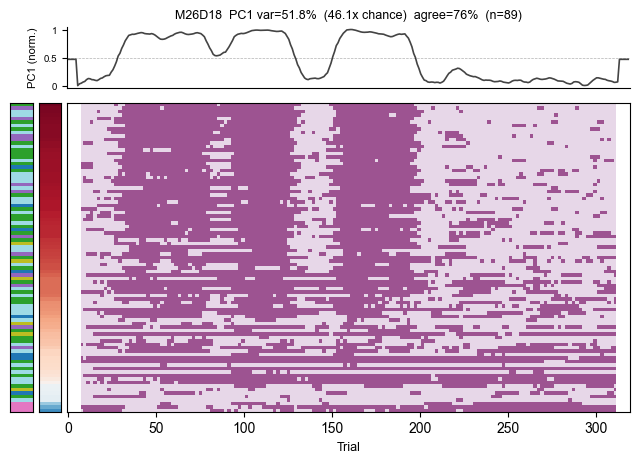

In [5]:
from IPython.display import display as _disp

EX_MOUSE, EX_DAY = 26, 18

tcs_ex, _, _, last_ephys_bin_ex, beh_ex, clusters_ex =     compute_vr_tcs(EX_MOUSE, EX_DAY, source_path=SOURCE_PATH)

_sess_ex = df_all[(df_all['mouse'] == EX_MOUSE) & (df_all['day'] == EX_DAY)]
ex_labels, ex_scx, ex_region = [], [], []
for _, row in _sess_ex.iterrows():
    lab = compute_anchoring_labels(int(row['cluster_id']), tcs_ex)
    if lab is not None:
        ex_labels.append(lab)
        ex_scx.append(float(row['SC_x']) if pd.notna(row['SC_x']) else np.nan)
        ex_region.append(str(row.get('brain_region', 'unknown')))

n_cells = len(ex_labels)
reg_counts = pd.Series(ex_region).value_counts().to_dict()
print(f'M{EX_MOUSE}D{EX_DAY}: {n_cells} cells — ' +
      '  '.join(f'{r}={c}' for r, c in reg_counts.items()))

# PCA: find cells that agree with the dominant switching pattern
# cell_corr[i] = Pearson r between cell i's smoothed labels and PC1.
# No pre-averaging — a switching subpopulation will dominate PC1 even if
# most cells do not participate.
trial_score, cell_corr, var_expl, enrichment = _pca_cell_agreement(ex_labels)
max_trials      = len(trial_score)
agree_frac      = float((cell_corr > 0.3).sum() / n_cells)
pc1_enrichment  = float(enrichment[0])
pc1_dominance   = float(enrichment[0] / enrichment[1]) if len(enrichment) > 1 else float('nan')
enrich_str      = '  '.join(f'PC{i+1}={e:.1f}x' for i, e in enumerate(enrichment))
print(f'{enrich_str}  |  dominance(PC1/PC2)={pc1_dominance:.1f}')
print(f'agreeing (r>0.3): {int((cell_corr > 0.3).sum())}/{n_cells}  ({agree_frac:.0%})')

# Sort cells by PC1 correlation descending (most agreeing at top)
sort_order    = np.argsort(-cell_corr).tolist()
mat_disp_all  = np.full((n_cells, max_trials), np.nan)
for i, lab in enumerate(ex_labels):
    mat_disp_all[i, :len(lab)] = lab
mat_plot      = mat_disp_all[sort_order]
region_sorted = [ex_region[i] for i in sort_order]
corr_sorted   = cell_corr[sort_order]

# Figure: 3 col x 2 row
# Row 0: [blank][blank][PC1 trial score]
# Row 1: [region strip][PC1 correlation strip][anchoring raster]
fig_ex, axes_ex = plt.subplots(
    2, 3, figsize=(8, 5),
    gridspec_kw=dict(height_ratios=[1, 5],
                     width_ratios=[0.04, 0.04, 1],
                     hspace=0.08, wspace=0.03)
)
axes_ex[0, 0].axis('off'); axes_ex[0, 1].axis('off')

ax_maps  = axes_ex[0, 2]
trial_ax = np.arange(max_trials)
ts_norm  = (trial_score - trial_score.min()) / (trial_score.max() - trial_score.min() + 1e-8)
ax_maps.plot(trial_ax, ts_norm, color='#444444', lw=1.2)
ax_maps.axhline(0.5, color='k', lw=0.5, ls='--', alpha=0.3)
ax_maps.set_xlim(0, max_trials); ax_maps.set_ylim(-0.05, 1.05)
ax_maps.set_yticks([0, 0.5, 1]); ax_maps.set_yticklabels(['0', '0.5', '1'], fontsize=7)
ax_maps.set_ylabel('PC1 (norm.)', fontsize=8); ax_maps.set_xticks([])
ax_maps.tick_params(labelsize=7)
ax_maps.spines['top'].set_visible(False); ax_maps.spines['right'].set_visible(False)
ax_maps.set_title(
    f'M{EX_MOUSE}D{EX_DAY}  PC1 var={var_expl:.1%}  ({pc1_enrichment:.1f}x chance)  agree={agree_frac:.0%}  (n={n_cells})',
    fontsize=9
)

ax_reg  = axes_ex[1, 0]; ax_cl = axes_ex[1, 1]; ax_rast = axes_ex[1, 2]

_unique_regs_ex = sorted(set(region_sorted))
_reg_to_idx_ex  = {r: i for i, r in enumerate(_unique_regs_ex)}
reg_vals = np.array([_reg_to_idx_ex[r] for r in region_sorted])[:, np.newaxis]
ax_reg.imshow(reg_vals, aspect='auto',
              cmap=plt.cm.get_cmap('tab20', len(_unique_regs_ex)),
              vmin=-0.5, vmax=len(_unique_regs_ex) - 0.5,
              interpolation='nearest', origin='upper')
ax_reg.set_xticks([]); ax_reg.set_yticks([])

# Correlation strip: red = agrees with PC1, white = no correlation, blue = anti
ax_cl.imshow(corr_sorted[:, np.newaxis], aspect='auto',
             cmap='RdBu_r', vmin=-1, vmax=1,
             interpolation='nearest', origin='upper')
ax_cl.set_xticks([]); ax_cl.set_yticks([])

plot_mat_ex = np.where(np.isnan(mat_plot), 2.0, mat_plot)
cmap_ex     = ListedColormap([COLOR_NON_ANCHOR, COLOR_ANCHOR, 'white'])
norm_ex     = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_ex.N)
ax_rast.imshow(plot_mat_ex, aspect='auto', cmap=cmap_ex, norm=norm_ex,
               interpolation='nearest', origin='upper')
ax_rast.set_xlabel('Trial', fontsize=9); ax_rast.set_yticks([])

_disp(fig_ex)
plt.close(fig_ex)

In [6]:
import matplotlib; matplotlib.use('Agg')
from matplotlib.patches import Patch

switching_stats = []
cell_rows       = []
acf_data        = []

def _simplify_region(reg):
    for prefix in ('ENT', 'VIS', 'PAR', 'PRE', 'SUB'):
        if reg.upper().startswith(prefix):
            return prefix
    return reg[:3] if len(reg) >= 3 else reg


def _session_figure(mouse, day, labels, regions):
    n_cells = len(labels)

    trial_score, cell_corr, var_expl, enrichment = _pca_cell_agreement(labels)
    max_trials     = len(trial_score)
    agree_frac     = float((cell_corr > 0.3).sum() / n_cells)
    pc1_enrichment = float(enrichment[0])
    pc1_dominance  = float(enrichment[0] / enrichment[1]) if len(enrichment) > 1 else np.nan

    sort_order    = np.argsort(-cell_corr).tolist()
    mat_disp      = np.full((n_cells, max_trials), np.nan)
    for i, lab in enumerate(labels):
        mat_disp[i, :len(lab)] = lab
    mat_plot      = mat_disp[sort_order]
    region_sorted = [regions[i] for i in sort_order]
    corr_sorted   = cell_corr[sort_order]

    fig, axes = plt.subplots(
        2, 3, figsize=(8, 5),
        gridspec_kw=dict(height_ratios=[1, 5],
                         width_ratios=[0.04, 0.04, 1],
                         hspace=0.08, wspace=0.03)
    )
    axes[0, 0].axis('off'); axes[0, 1].axis('off')

    ax_maps  = axes[0, 2]
    trial_ax = np.arange(max_trials)
    ts_norm  = (trial_score - trial_score.min()) / (trial_score.max() - trial_score.min() + 1e-8)
    ax_maps.plot(trial_ax, ts_norm, color='#444444', lw=1.2)
    ax_maps.axhline(0.5, color='k', lw=0.5, ls='--', alpha=0.3)
    ax_maps.set_xlim(0, max_trials); ax_maps.set_ylim(-0.05, 1.05)
    ax_maps.set_yticks([0, 0.5, 1]); ax_maps.set_yticklabels(['0', '0.5', '1'], fontsize=7)
    ax_maps.set_ylabel('PC1 (norm.)', fontsize=8); ax_maps.set_xticks([])
    ax_maps.tick_params(labelsize=7)
    ax_maps.spines['top'].set_visible(False); ax_maps.spines['right'].set_visible(False)
    ax_maps.set_title(
        f'M{mouse}D{day}  PC1 var={var_expl:.1%}  ({pc1_enrichment:.1f}x chance)  agree={agree_frac:.0%}  (n={n_cells})',
        fontsize=9)

    ax_reg = axes[1, 0]; ax_cl = axes[1, 1]; ax_rast = axes[1, 2]
    _unique_regs = sorted(set(region_sorted))
    _reg_to_idx  = {r: i for i, r in enumerate(_unique_regs)}
    reg_cmap_obj = plt.cm.get_cmap('tab20', len(_unique_regs))

    reg_vals = np.array([_reg_to_idx[r] for r in region_sorted])[:, np.newaxis]
    ax_reg.imshow(reg_vals, aspect='auto',
                  cmap=reg_cmap_obj,
                  vmin=-0.5, vmax=len(_unique_regs) - 0.5,
                  interpolation='nearest', origin='upper')
    ax_reg.set_xticks([]); ax_reg.set_yticks([])

    # region legend in top-right of PC1 panel
    legend_handles = [Patch(facecolor=reg_cmap_obj(i), label=reg)
                      for i, reg in enumerate(_unique_regs)]
    ax_maps.legend(handles=legend_handles, fontsize=6, loc='upper right',
                   frameon=False, title='Region', title_fontsize=6,
                   ncol=min(3, len(_unique_regs)))

    ax_cl.imshow(corr_sorted[:, np.newaxis], aspect='auto',
                 cmap='RdBu_r', vmin=-1, vmax=1,
                 interpolation='nearest', origin='upper')
    ax_cl.set_xticks([]); ax_cl.set_yticks([])

    plot_mat = np.where(np.isnan(mat_plot), 2.0, mat_plot)
    cmap_r   = ListedColormap([COLOR_NON_ANCHOR, COLOR_ANCHOR, 'white'])
    norm_r   = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_r.N)
    ax_rast.imshow(plot_mat, aspect='auto', cmap=cmap_r, norm=norm_r,
                   interpolation='nearest', origin='upper')
    ax_rast.set_xlabel('Trial', fontsize=9); ax_rast.set_yticks([])

    return fig, (n_cells, agree_frac, var_expl, pc1_enrichment, pc1_dominance, enrichment, cell_corr, max_trials)


for mouse, day in all_sessions:
    try:
        tcs, _, _, _, _, _ = compute_vr_tcs(mouse, day, source_path=SOURCE_PATH)
    except Exception as e:
        print(f'M{mouse}D{day}: skipped (load error): {e}')
        continue

    _sess = df_all[(df_all['mouse']==mouse) & (df_all['day']==day)]

    labels, regions, cids = [], [], []
    for _, row in _sess.iterrows():
        lab = compute_anchoring_labels(int(row['cluster_id']), tcs)
        if lab is not None:
            labels.append(lab)
            regions.append(_simplify_region(str(row.get('brain_region', 'unknown'))))
            cids.append(int(row['cluster_id']))

    if len(labels) < 4:
        print(f'M{mouse}D{day}: too few cells ({len(labels)}) — skipped')
        continue

    fig, stats = _session_figure(mouse, day, labels, regions)
    n_cells_s, agree_frac_s, var_expl_s, enrich_s, dom_s, enrich_all_s, cell_corr_s, max_trials_s = stats
    _enrich_arr  = np.array(enrich_all_s)
    _mp_bound    = (1 + np.sqrt(n_cells_s / max(max_trials_s, 1))) ** 2
    n_dims_mp    = int((_enrich_arr > _mp_bound).sum())
    _eigs        = _enrich_arr / n_cells_s
    part_ratio   = float(_eigs.sum() ** 2 / (_eigs ** 2).sum())
    session_passes = (agree_frac_s > 0.3 and enrich_s > 1.5 and dom_s > 2)
    switching_stats.append({'mouse': mouse, 'day': day,
                             'n_cells': n_cells_s,
                             'agree_frac': agree_frac_s,
                             'var_expl': var_expl_s,
                             'pc1_enrichment': enrich_s,
                             'pc1_dominance': dom_s,
                             'n_dims_mp': n_dims_mp,
                             'participation_ratio': part_ratio,
                             'n_trials': max_trials_s,
                             'session_passes': session_passes,
                             'enrichment_all': enrich_all_s.tolist()})
    for j, (cid, corr, reg) in enumerate(zip(cids, cell_corr_s, regions)):
        acf   = _cell_autocorr(labels[j])
        lag1  = float(acf[0]) if not np.isnan(acf[0]) else np.nan
        passes = session_passes and bool(corr > 0.3)
        cell_rows.append({
            'mouse': mouse, 'day': day, 'cluster_id': cid, 'region': reg,
            'cell_corr': round(float(corr), 4),
            'cell_agrees': bool(corr > 0.3),
            'lag1_autocorr': round(lag1, 4) if not np.isnan(lag1) else np.nan,
            'n_cells': n_cells_s,
            'agree_frac': round(agree_frac_s, 4),
            'var_expl': round(var_expl_s, 4),
            'pc1_enrichment': round(enrich_s, 4),
            'pc1_dominance': round(dom_s, 4),
            'session_passes': session_passes,
            'passes_criteria': passes,
        })
        acf_data.append({'passes_criteria': passes, 'acf': acf.tolist()})

    if session_passes:
        out_path = CATALOGUE_DIR / f'M{mouse}D{day:02d}_anchoring.pdf'
        fig.savefig(out_path, bbox_inches='tight', dpi=150)
        print(f'Saved  M{mouse}D{day:02d}  n={n_cells_s}  '
              f'PC1={var_expl_s:.1%}  ({enrich_s:.1f}x)  dom={dom_s:.1f}  agree={agree_frac_s:.0%}  -> {out_path.name}')
    else:
        print(f'Skip   M{mouse}D{day:02d}  n={n_cells_s}  '
              f'PC1={var_expl_s:.1%}  ({enrich_s:.1f}x)  dom={dom_s:.1f}  agree={agree_frac_s:.0%}  (did not pass)')
    plt.close(fig)

print('\nAll sessions complete.')
df_switching = pd.DataFrame(switching_stats).sort_values('agree_frac', ascending=False)
print(df_switching.to_string(index=False))


Skip   M20D14  n=198  PC1=15.7%  (31.1x)  dom=1.5  agree=36%  (did not pass)
Skip   M20D15  n=65  PC1=10.4%  (6.7x)  dom=1.3  agree=23%  (did not pass)
Skip   M20D16  n=209  PC1=7.0%  (14.6x)  dom=1.3  agree=16%  (did not pass)
Skip   M20D17  n=107  PC1=9.4%  (10.0x)  dom=1.3  agree=11%  (did not pass)
Skip   M20D18  n=133  PC1=9.7%  (12.9x)  dom=1.3  agree=16%  (did not pass)
Skip   M20D19  n=108  PC1=8.5%  (9.1x)  dom=1.2  agree=14%  (did not pass)
Skip   M20D20  n=100  PC1=8.9%  (8.9x)  dom=1.2  agree=52%  (did not pass)
Skip   M20D21  n=107  PC1=8.3%  (8.9x)  dom=1.1  agree=16%  (did not pass)
Skip   M20D22  n=66  PC1=11.8%  (7.8x)  dom=1.5  agree=8%  (did not pass)
Skip   M20D23  n=75  PC1=13.0%  (9.8x)  dom=1.5  agree=33%  (did not pass)
Skip   M20D24  n=81  PC1=7.5%  (6.1x)  dom=1.1  agree=12%  (did not pass)
Saved  M20D25  n=35  PC1=22.7%  (7.9x)  dom=2.5  agree=34%  -> M20D25_anchoring.pdf
Skip   M20D26  n=150  PC1=9.2%  (13.8x)  dom=1.5  agree=30%  (did not pass)
Skip   M21D1

## Cross-session switching summary

Sessions ranked by `agree_frac` — the fraction of cells with PC1 correlation > 0.3.

**`pc1_enrichment = var_expl * n_cells`** corrects for the fact that PC1 variance
explained has a noise floor of 1/n_cells: for purely random labels each of the n_cells
PCs would explain exactly 1/n_cells of variance, so enrichment = 1.0 is chance.
Enrichment > 2 means PC1 explains at least twice what noise would predict.

Bar colour encodes enrichment (darker = more structured).  Annotated value is
`agree_frac`.  Sessions worth inspecting have both high enrichment (> 2) and high
agree_frac (> 0.3).

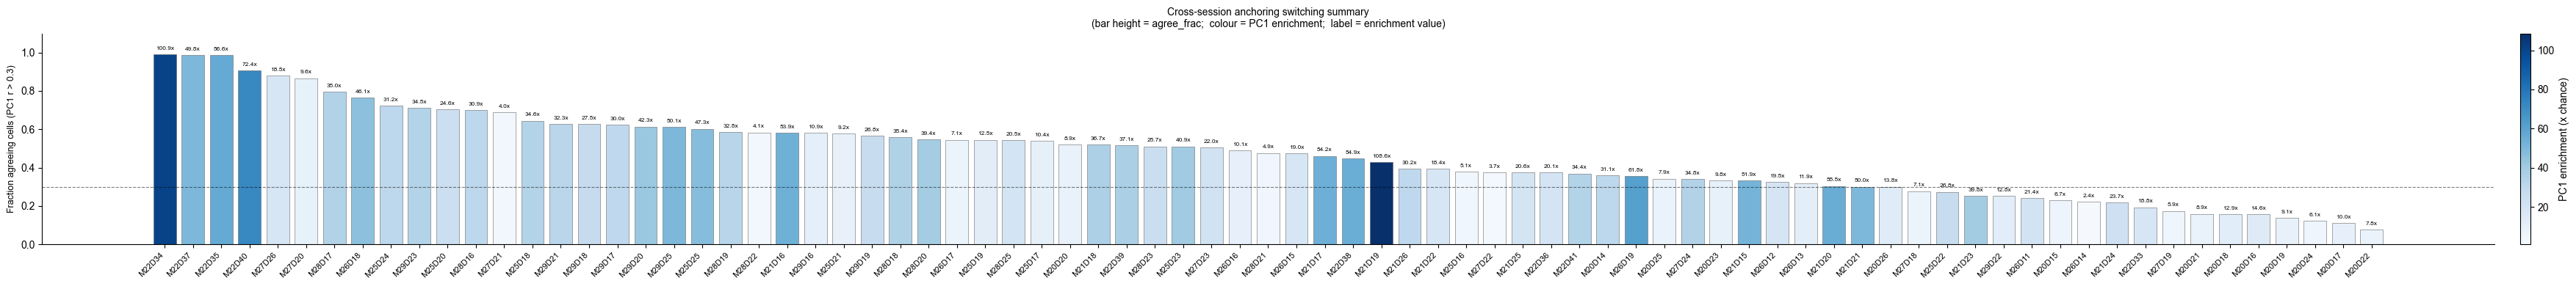

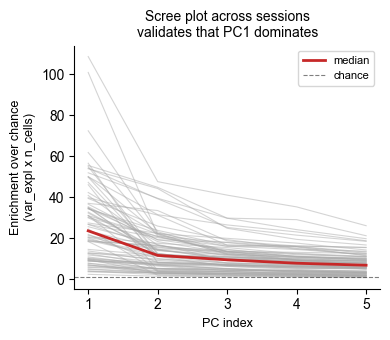

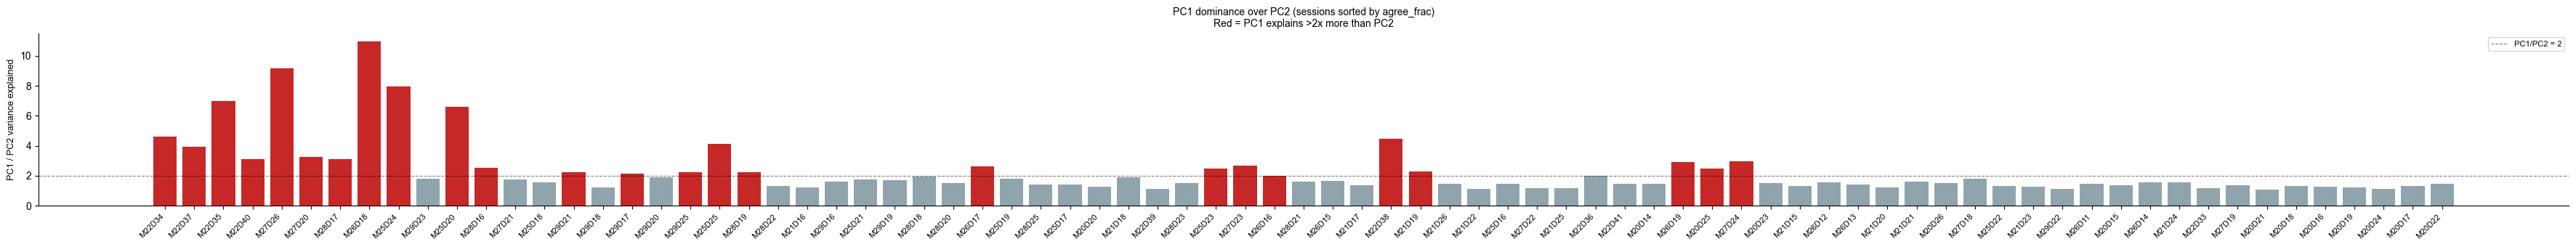


Top sessions (agree_frac > 0.3  AND  pc1_enrichment > 1.5  AND  pc1_dominance > 2):
 mouse  day  n_cells  agree_frac  var_expl  pc1_enrichment  pc1_dominance
    22   34      240    0.991667  0.420214      100.851256       4.631315
    22   37      163    0.987730  0.305708       49.830420       3.923952
    22   35      150    0.986667  0.377364       56.604611       7.007244
    22   40      315    0.907937  0.229894       72.416743       3.121592
    27   26       33    0.878788  0.559181       18.452968       9.155276
    27   20       30    0.866667  0.320794        9.623811       3.247947
    28   17       98    0.795918  0.357218       35.007374       3.126415
    26   18       89    0.764045  0.518224       46.121971      10.966853
    25   24       65    0.723077  0.479264       31.152145       7.957024
    25   20       61    0.704918  0.402507       24.552946       6.599990
    28   16      100    0.700000  0.309034       30.903427       2.506832
    29   21      137    0.6

In [7]:
%matplotlib inline
from IPython.display import display as _disp

if not switching_stats:
    print('No sessions processed — run cell-main first')
else:
    df_sw = pd.DataFrame(switching_stats).sort_values('agree_frac', ascending=False)

    import matplotlib.cm as _cm
    import matplotlib.colors as _mcolors

    fig_sw, ax_sw = plt.subplots(figsize=(max(5, len(df_sw) * 0.45), 4))
    xlabels = [f"M{int(r.mouse)}D{int(r.day)}" for _, r in df_sw.iterrows()]

    # colour bars by pc1_enrichment; cap colormap at 5x for visual range
    enrich_vals = df_sw['pc1_enrichment'].values
    norm_enrich = _mcolors.Normalize(vmin=1, vmax=max(5, enrich_vals.max()))
    cmap_enrich = _cm.get_cmap('Blues')
    bar_colors  = [cmap_enrich(norm_enrich(e)) for e in enrich_vals]

    ax_sw.bar(np.arange(len(df_sw)), df_sw['agree_frac'],
              color=bar_colors, edgecolor='0.4', linewidth=0.4)
    ax_sw.axhline(0.3, color='k', lw=0.8, ls='--', alpha=0.5, label='agree=0.3')
    ax_sw.set_xticks(np.arange(len(df_sw)))
    ax_sw.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
    ax_sw.set_ylabel('Fraction agreeing cells (PC1 r > 0.3)', fontsize=9)
    ax_sw.set_ylim(0, 1.1)
    ax_sw.set_title('Cross-session anchoring switching summary\n'
                    '(bar height = agree_frac;  colour = PC1 enrichment;  label = enrichment value)',
                    fontsize=10)
    ax_sw.spines['top'].set_visible(False); ax_sw.spines['right'].set_visible(False)

    sm = _cm.ScalarMappable(cmap=cmap_enrich, norm=norm_enrich)
    sm.set_array([])
    fig_sw.colorbar(sm, ax=ax_sw, label='PC1 enrichment (x chance)', pad=0.01,
                    fraction=0.03)

    for i, (_, r) in enumerate(df_sw.iterrows()):
        ax_sw.text(i, r.agree_frac + 0.02, f'{r.pc1_enrichment:.1f}x',
                   ha='center', va='bottom', fontsize=6)

    fig_sw.tight_layout()
    _disp(fig_sw)
    plt.close(fig_sw)

    # Scree plot: enrichment per PC across sessions
    # x = PC index, y = var_expl * n_cells (enrichment over chance)
    # One grey line per session; bold line = median across sessions.
    # Chance = 1.0 (horizontal dashed line).
    all_enrich = [r['enrichment_all'] for r in switching_stats if 'enrichment_all' in r]
    if all_enrich:
        max_k   = max(len(e) for e in all_enrich)
        enrich_mat = np.full((len(all_enrich), max_k), np.nan)
        for i, e in enumerate(all_enrich):
            enrich_mat[i, :len(e)] = e

        fig_sc, ax_sc = plt.subplots(figsize=(4, 3.5))
        pc_idx = np.arange(1, max_k + 1)
        for row in enrich_mat:
            ax_sc.plot(pc_idx[:len(row[~np.isnan(row)])],
                       row[~np.isnan(row)],
                       color='#aaaaaa', lw=0.8, alpha=0.5)
        med_line = np.nanmedian(enrich_mat, axis=0)
        ax_sc.plot(pc_idx, med_line, color='#c62828', lw=2.0, label='median')
        ax_sc.axhline(1.0, color='k', lw=0.8, ls='--', alpha=0.5, label='chance')
        ax_sc.set_xlabel('PC index', fontsize=9)
        ax_sc.set_ylabel('Enrichment over chance\n(var_expl x n_cells)', fontsize=9)
        ax_sc.set_title('Scree plot across sessions\n'
                        'validates that PC1 dominates', fontsize=10)
        ax_sc.set_xticks(pc_idx)
        ax_sc.legend(fontsize=8)
        ax_sc.spines['top'].set_visible(False); ax_sc.spines['right'].set_visible(False)
        fig_sc.tight_layout()
        _disp(fig_sc)
        plt.close(fig_sc)

    # Dominance bar chart: PC1/PC2 ratio per session, sorted by agree_frac
    # Ratio > 2 (dashed line) means PC1 explains at least 2x more than PC2.
    # n_cells cancels in the ratio so no enrichment correction needed here.
    if 'pc1_dominance' in df_sw.columns:
        fig_dom, ax_dom = plt.subplots(figsize=(max(5, len(df_sw) * 0.45), 3.5))
        dom_vals   = df_sw['pc1_dominance'].values
        dom_colors = ['#c62828' if d > 2 else '#90a4ae' for d in dom_vals]
        ax_dom.bar(np.arange(len(df_sw)), dom_vals, color=dom_colors, edgecolor='none')
        ax_dom.axhline(2, color='k', lw=0.8, ls='--', alpha=0.5, label='PC1/PC2 = 2')
        ax_dom.set_xticks(np.arange(len(df_sw)))
        ax_dom.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)
        ax_dom.set_ylabel('PC1 / PC2 variance explained', fontsize=9)
        ax_dom.set_title('PC1 dominance over PC2 (sessions sorted by agree_frac)\n'
                         'Red = PC1 explains >2x more than PC2', fontsize=10)
        ax_dom.legend(fontsize=8)
        ax_dom.spines['top'].set_visible(False); ax_dom.spines['right'].set_visible(False)
        fig_dom.tight_layout()
        _disp(fig_dom)
        plt.close(fig_dom)

    print('\nTop sessions (agree_frac > 0.3  AND  pc1_enrichment > 1.5  AND  pc1_dominance > 2):')
    _top = df_sw[(df_sw['agree_frac'] > 0.3) &
                 (df_sw['pc1_enrichment'] > 1.5) &
                 (df_sw['pc1_dominance'] > 2)]
    if len(_top):
        print(_top[['mouse','day','n_cells','agree_frac','var_expl',
                     'pc1_enrichment','pc1_dominance']].to_string(index=False))
    else:
        print('  (none)')

3656 cells, 25 sessions


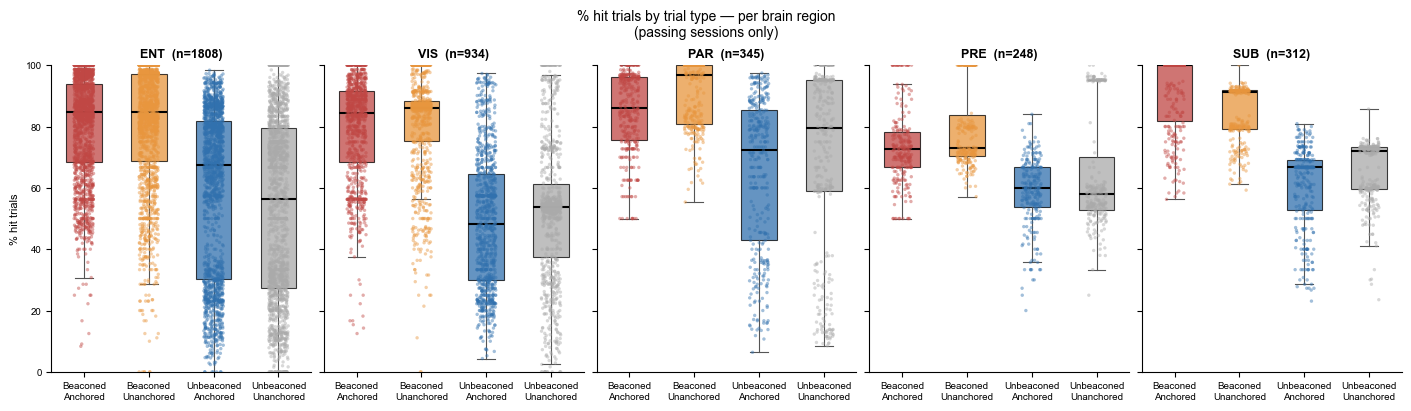

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CONDITIONS  = ['cued_anchored', 'cued_unanchored', 'uncued_anchored', 'uncued_unanchored']
CON_LABELS  = ['Beaconed\nAnchored', 'Beaconed\nUnanchored',
               'Unbeaconed\nAnchored', 'Unbeaconed\nUnanchored']
CON_COLORS  = ['#c04744', '#e8963e', '#3171ae', '#aaaaaa']
REGIONS     = ['ENT', 'VIS', 'PAR', 'PRE', 'SUB']

passing_days = {(s['mouse'], s['day']) for s in switching_stats if s['session_passes']}

condition_rows = []

for mouse, day in all_sessions:
    if (mouse, day) not in passing_days:
        continue
    try:
        tcs, _, _, _, beh, _ = compute_vr_tcs(mouse, day, source_path=SOURCE_PATH)
    except Exception as e:
        print(f'M{mouse}D{day}: load error {e}'); continue
    try:
        trial_types   = np.array(beh['trials']['type'])
        trial_perfs   = np.array(beh['trials'].performance)
        beaconed_mask = trial_types == 'b'
        unbeac_mask   = trial_types == 'nb'
    except Exception as e:
        print(f'M{mouse}D{day}: trial col error {e}'); continue

    _sess = df_all[(df_all['mouse'] == mouse) & (df_all['day'] == day)]
    for _, row in _sess.iterrows():
        lab = compute_anchoring_labels(int(row['cluster_id']), tcs)
        if lab is None:
            continue
        region = _simplify_region(str(row.get('brain_region', 'unknown')))
        n_t    = len(lab)
        tt     = trial_types[:n_t]
        tp     = trial_perfs[:n_t]
        anch   = lab.astype(bool)

        def _pct_hits(type_mask, anch_mask):
            mask  = type_mask[:n_t] & anch_mask
            total = mask.sum()
            return 100 * np.sum(tp[mask] == 'hit') / total if total > 0 else np.nan

        condition_rows.append({
            'mouse':             mouse,
            'day':               day,
            'cluster_id':        int(row['cluster_id']),
            'region':            region,
            'cell_type':         str(row.get('cell_type', '')),
            'cued_anchored':     _pct_hits(beaconed_mask, anch),
            'cued_unanchored':   _pct_hits(beaconed_mask, ~anch),
            'uncued_anchored':   _pct_hits(unbeac_mask,   anch),
            'uncued_unanchored': _pct_hits(unbeac_mask,   ~anch),
        })

df_cond = pd.DataFrame(condition_rows)
print(f'{len(df_cond)} cells, {df_cond.groupby(["mouse","day"]).ngroups} sessions')

regions_present = [r for r in REGIONS if r in df_cond['region'].values]
n_reg = len(regions_present)
fig, axes = plt.subplots(1, n_reg, figsize=(2.8 * n_reg, 4),
                         sharey=True, constrained_layout=True)
if n_reg == 1:
    axes = [axes]
rng = np.random.default_rng(0)

for ax, reg in zip(axes, regions_present):
    sub  = df_cond[df_cond['region'] == reg]
    data = [sub[c].dropna().values for c in CONDITIONS]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                    medianprops=dict(color='k', lw=1.5),
                    whiskerprops=dict(lw=0.8, color='#555'),
                    capprops=dict(lw=0.8, color='#555'),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, markeredgewidth=0))
    for patch, color in zip(bp['boxes'], CON_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.75); patch.set_linewidth(0.8)
    for xi, (d, color) in enumerate(zip(data, CON_COLORS), start=1):
        jitter = rng.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(xi + jitter, d, color=color, s=6, alpha=0.45, zorder=3, edgecolors='none')
    ax.set_xticks(range(1, len(CONDITIONS) + 1))
    ax.set_xticklabels(CON_LABELS, fontsize=7)
    ax.set_title(f'{reg}  (n={len(sub)})', fontsize=9, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.set_ylim(0, 100)

axes[0].set_ylabel('% hit trials', fontsize=8)
fig.suptitle('% hit trials by trial type — per brain region\n(passing sessions only)', fontsize=10)
fig.savefig(CATALOGUE_DIR / 'anchoring_hit_pct_by_region.pdf', bbox_inches='tight', dpi=200)
display(fig); plt.close()

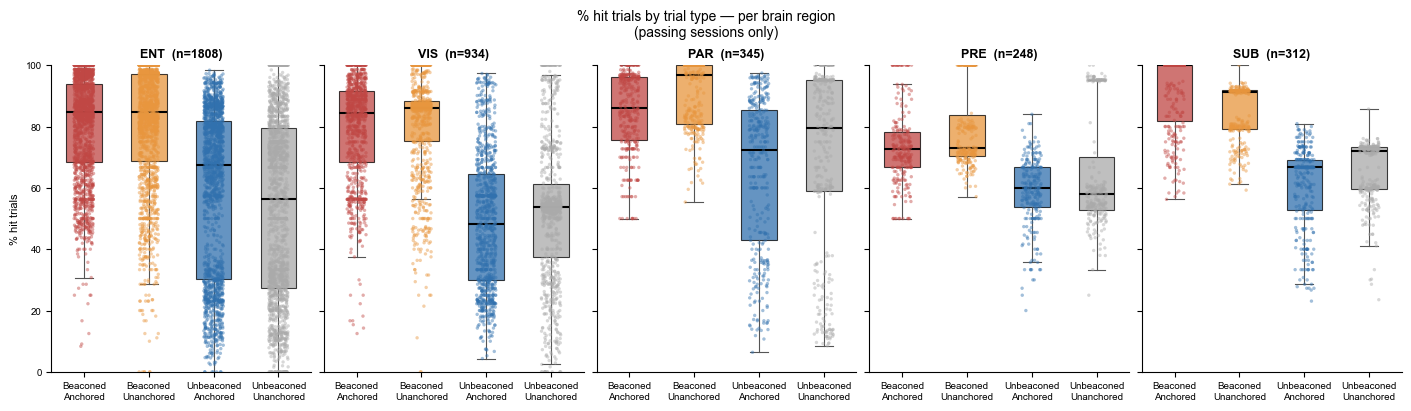

In [9]:
regions_present = [r for r in REGIONS if r in df_cond['region'].values]
n_reg = len(regions_present)
fig, axes = plt.subplots(1, n_reg, figsize=(2.8 * n_reg, 4),
                         sharey=True, constrained_layout=True)
if n_reg == 1:
    axes = [axes]
rng = np.random.default_rng(0)

for ax, reg in zip(axes, regions_present):
    sub  = df_cond[df_cond['region'] == reg]
    data = [sub[c].dropna().values for c in CONDITIONS]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                    medianprops=dict(color='k', lw=1.5),
                    whiskerprops=dict(lw=0.8, color='#555'),
                    capprops=dict(lw=0.8, color='#555'),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, markeredgewidth=0))
    for patch, color in zip(bp['boxes'], CON_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.75); patch.set_linewidth(0.8)
    for xi, (d, color) in enumerate(zip(data, CON_COLORS), start=1):
        jitter = rng.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(xi + jitter, d, color=color, s=6, alpha=0.45, zorder=3, edgecolors='none')
    ax.set_xticks(range(1, len(CONDITIONS) + 1))
    ax.set_xticklabels(CON_LABELS, fontsize=7)
    ax.set_title(f'{reg}  (n={len(sub)})', fontsize=9, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.set_ylim(0, 100)

axes[0].set_ylabel('% hit trials', fontsize=8)
fig.suptitle('% hit trials by trial type — per brain region\n(passing sessions only)', fontsize=10)
fig.savefig(CATALOGUE_DIR / 'anchoring_hit_pct_by_region.pdf', bbox_inches='tight', dpi=200)
display(fig); plt.close()

ENT grid cells: 213 cells, 17 sessions


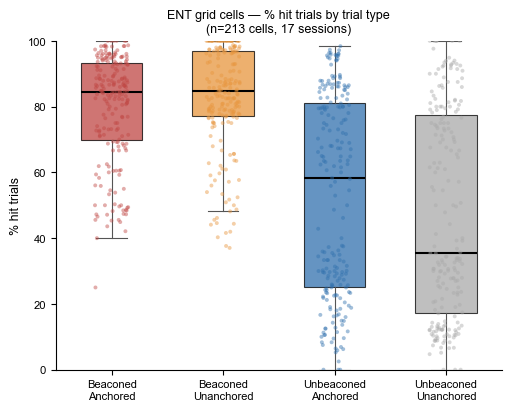

In [10]:
GC_TYPES = ('GC', 'cmGC', 'ncmGC')

df_ent_gc = df_cond[
    (df_cond['region'] == 'ENT') &
    (df_cond['cell_type'].isin(GC_TYPES))
].copy()

n_sess = df_ent_gc.groupby(['mouse', 'day']).ngroups
print(f'ENT grid cells: {len(df_ent_gc)} cells, {n_sess} sessions')

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
data = [df_ent_gc[c].dropna().values for c in CONDITIONS]
rng  = np.random.default_rng(0)

bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                medianprops=dict(color='k', lw=1.5),
                whiskerprops=dict(lw=0.8, color='#555'),
                capprops=dict(lw=0.8, color='#555'),
                flierprops=dict(marker='o', markersize=2, alpha=0.4, markeredgewidth=0))
for patch, color in zip(bp['boxes'], CON_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75); patch.set_linewidth(0.8)
for xi, (d, color) in enumerate(zip(data, CON_COLORS), start=1):
    jitter = rng.uniform(-0.15, 0.15, size=len(d))
    ax.scatter(xi + jitter, d, color=color, s=8, alpha=0.45, zorder=3, edgecolors='none')

ax.set_xticks(range(1, len(CONDITIONS) + 1))
ax.set_xticklabels(CON_LABELS, fontsize=8)
ax.set_ylabel('% hit trials', fontsize=9)
ax.set_ylim(0, 100)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=8)
ax.set_title(f'ENT grid cells — % hit trials by trial type\n'
             f'(n={len(df_ent_gc)} cells, {n_sess} sessions)', fontsize=9)

fig.savefig(CATALOGUE_DIR / 'anchoring_hit_pct_ENT_GC.pdf', bbox_inches='tight', dpi=200)
display(fig); plt.close()


ent_location
medial     167
lateral     46
Name: count, dtype: int64


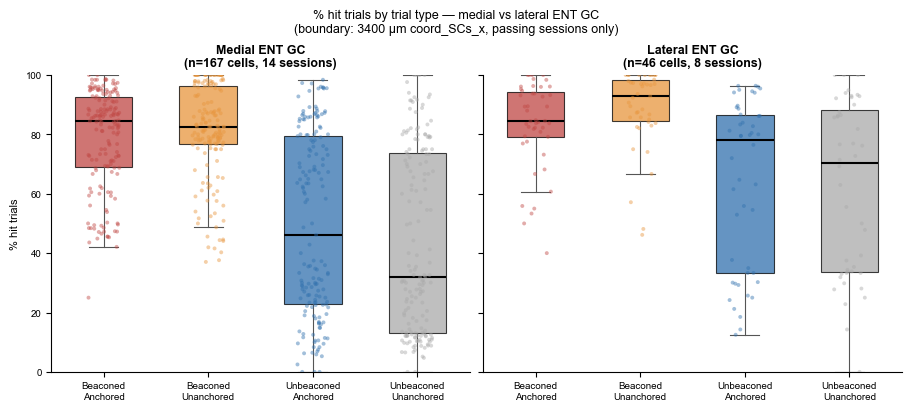

In [11]:
# Load brain locations and assign medial/lateral to df_ent_gc
MEDLAT_BOUNDARY = 3400

locs = pd.read_csv(f'{SOURCE_PATH}/all_cluster_brain_locations_chris.csv')
locs['coord_SCs_x'] = locs['coord_SCs_x'] * -1   # sign convention from xgboost scripts

# Build a lookup: (mouse, day, cluster_id) → medial or lateral
def _medlat(mouse, day, cluster_id):
    row = locs[
        (locs['mouse'] == mouse) &
        (locs['day'] == day) &
        (locs['cluster_id'] == cluster_id)
    ]
    if row.empty:
        return np.nan
    x = row['coord_SCs_x'].values[0]
    return 'medial' if x < MEDLAT_BOUNDARY else 'lateral'

df_ent_gc = df_ent_gc.copy()
df_ent_gc['ent_location'] = df_ent_gc.apply(
    lambda r: _medlat(r['mouse'], r['day'], r['cluster_id']), axis=1
)

print(df_ent_gc['ent_location'].value_counts())

# ── Plot ──────────────────────────────────────────────────────────────────────
locations_present = [l for l in ('medial', 'lateral')
                     if l in df_ent_gc['ent_location'].values]

fig, axes = plt.subplots(1, len(locations_present),
                         figsize=(4.5 * len(locations_present), 4),
                         sharey=True, constrained_layout=True)
if len(locations_present) == 1:
    axes = [axes]

rng = np.random.default_rng(0)

for ax, loc in zip(axes, locations_present):
    sub  = df_ent_gc[df_ent_gc['ent_location'] == loc]
    data = [sub[c].dropna().values for c in CONDITIONS]
    n_sess_loc = sub.groupby(['mouse', 'day']).ngroups

    bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                    medianprops=dict(color='k', lw=1.5),
                    whiskerprops=dict(lw=0.8, color='#555'),
                    capprops=dict(lw=0.8, color='#555'),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, markeredgewidth=0))
    for patch, color in zip(bp['boxes'], CON_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.75); patch.set_linewidth(0.8)
    for xi, (d, color) in enumerate(zip(data, CON_COLORS), start=1):
        jitter = rng.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(xi + jitter, d, color=color, s=8, alpha=0.45, zorder=3, edgecolors='none')

    ax.set_xticks(range(1, len(CONDITIONS) + 1))
    ax.set_xticklabels(CON_LABELS, fontsize=7)
    ax.set_title(f'{loc.capitalize()} ENT GC\n(n={len(sub)} cells, {n_sess_loc} sessions)',
                 fontsize=9, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.set_ylim(0, 100)

axes[0].set_ylabel('% hit trials', fontsize=8)
fig.suptitle(f'% hit trials by trial type — medial vs lateral ENT GC\n'
             f'(boundary: {MEDLAT_BOUNDARY} µm coord_SCs_x, passing sessions only)',
             fontsize=9)

fig.savefig(CATALOGUE_DIR / 'anchoring_hit_pct_ENT_GC_medlat.pdf',
            bbox_inches='tight', dpi=200)
display(fig); plt.close()


ent_location
lateral    920
medial     888
Name: count, dtype: int64
ent_location  cell_type
lateral       GC            46
              NG           715
              Other        159
medial        GC           167
              NG           628
              Other         93
dtype: int64


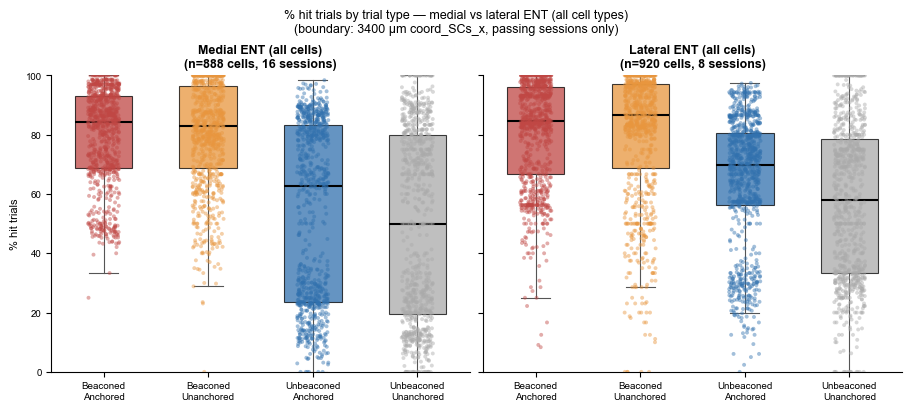

In [12]:
# All ENT cells regardless of cell type
df_ent_all = df_cond[df_cond['region'] == 'ENT'].copy()

df_ent_all['ent_location'] = df_ent_all.apply(
    lambda r: _medlat(r['mouse'], r['day'], r['cluster_id']), axis=1
)

print(df_ent_all['ent_location'].value_counts())
print(df_ent_all.groupby(['ent_location', 'cell_type']).size())

locations_present = [l for l in ('medial', 'lateral')
                     if l in df_ent_all['ent_location'].values]

fig, axes = plt.subplots(1, len(locations_present),
                         figsize=(4.5 * len(locations_present), 4),
                         sharey=True, constrained_layout=True)
if len(locations_present) == 1:
    axes = [axes]

rng = np.random.default_rng(0)

for ax, loc in zip(axes, locations_present):
    sub  = df_ent_all[df_ent_all['ent_location'] == loc]
    data = [sub[c].dropna().values for c in CONDITIONS]
    n_sess_loc = sub.groupby(['mouse', 'day']).ngroups

    bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                    medianprops=dict(color='k', lw=1.5),
                    whiskerprops=dict(lw=0.8, color='#555'),
                    capprops=dict(lw=0.8, color='#555'),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, markeredgewidth=0))
    for patch, color in zip(bp['boxes'], CON_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.75); patch.set_linewidth(0.8)
    for xi, (d, color) in enumerate(zip(data, CON_COLORS), start=1):
        jitter = rng.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(xi + jitter, d, color=color, s=8, alpha=0.45, zorder=3, edgecolors='none')

    ax.set_xticks(range(1, len(CONDITIONS) + 1))
    ax.set_xticklabels(CON_LABELS, fontsize=7)
    ax.set_title(f'{loc.capitalize()} ENT (all cells)\n(n={len(sub)} cells, {n_sess_loc} sessions)',
                 fontsize=9, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.set_ylim(0, 100)

axes[0].set_ylabel('% hit trials', fontsize=8)
fig.suptitle(f'% hit trials by trial type — medial vs lateral ENT (all cell types)\n'
             f'(boundary: {MEDLAT_BOUNDARY} µm coord_SCs_x, passing sessions only)',
             fontsize=9)

fig.savefig(CATALOGUE_DIR / 'anchoring_hit_pct_ENT_all_medlat.pdf',
            bbox_inches='tight', dpi=200)
display(fig); plt.close()


ENT grid cells: 213 cells, 17 sessions


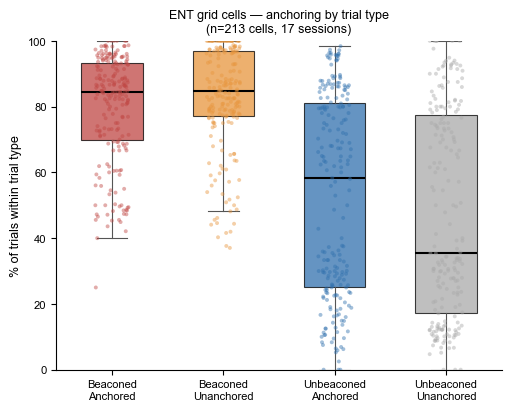

In [13]:
GC_TYPES = ('GC', 'cmGC', 'ncmGC')   # adjust if df_all uses different labels

df_ent_gc = df_cond[
    (df_cond['region'] == 'ENT') &
    (df_cond['cell_type'].isin(GC_TYPES))
].copy()

n_sess = df_ent_gc.groupby(['mouse', 'day']).ngroups
print(f'ENT grid cells: {len(df_ent_gc)} cells, {n_sess} sessions')

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
data = [df_ent_gc[c].dropna().values for c in CONDITIONS]
rng  = np.random.default_rng(0)

bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                medianprops=dict(color='k', lw=1.5),
                whiskerprops=dict(lw=0.8, color='#555'),
                capprops=dict(lw=0.8, color='#555'),
                flierprops=dict(marker='o', markersize=2, alpha=0.4, markeredgewidth=0))
for patch, color in zip(bp['boxes'], CON_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75); patch.set_linewidth(0.8)
for xi, (d, color) in enumerate(zip(data, CON_COLORS), start=1):
    jitter = rng.uniform(-0.15, 0.15, size=len(d))
    ax.scatter(xi + jitter, d, color=color, s=8, alpha=0.45, zorder=3, edgecolors='none')

ax.set_xticks(range(1, len(CONDITIONS) + 1))
ax.set_xticklabels(CON_LABELS, fontsize=8)
ax.set_ylabel('% of trials within trial type', fontsize=9)
ax.set_ylim(0, 100)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=8)
ax.set_title(f'ENT grid cells — anchoring by trial type\n'
             f'(n={len(df_ent_gc)} cells, {n_sess} sessions)', fontsize=9)

fig.savefig(CATALOGUE_DIR / 'anchoring_conditions_ENT_GC.pdf', bbox_inches='tight', dpi=200)
display(fig); plt.close()


## Cell inclusion flags

The table below records every cell across every processed session and whether it
passes the combined criteria for use in further analysis.

### Criteria

| Level | Criterion | Rationale |
|---|---|---|
| Session | `agree_frac > 0.3` | At least 30% of cells correlate with PC1 — session has a real population-level switching signal |
| Session | `pc1_enrichment > 1.5` | PC1 explains 50% more variance than chance (1/n_cells) — not pure noise |
| Session | `pc1_dominance > 2` | PC1 explains at least 2x more than PC2 — the structure is effectively 1-dimensional |
| Cell | `cell_corr > 0.3` | Individual cell Pearson r with PC1 — cell participates in the dominant switching pattern |

`passes_criteria = True` requires **all four** conditions to hold.

### What is filtered out

- **Sessions with low agree_frac**: No coherent population switching detected — the anchoring labels are either stable across all trials or switching independently per cell with no shared structure.
- **Sessions with low pc1_enrichment**: PC1 is not meaningfully above the noise floor expected from random binary labels — the variance is spread uniformly across PCs.
- **Sessions with low pc1_dominance**: More than one comparably sized switching pattern is present — the dominant axis is ambiguous and PC1 may not be representative.
- **Cells with low cell_corr**: Even within a passing session, individual cells that do not co-modulate with the dominant switching pattern are excluded — they may be driven by a different mechanism or simply be noisy.

Saved: /Users/harryclark/Documents/spatial-manifolds/data/task_anchoring_cell_flags.csv
Rows: 11088

Sessions:  25/79 pass session-level criteria
Cells:     2313/11088 pass combined criteria  (20.9%)
  APr: 0/43 (0.0%)
  ENT: 972/6990 (13.9%)
  HPF: 0/102 (0.0%)
  PAR: 274/682 (40.2%)
  POS: 0/4 (0.0%)
  PRE: 165/407 (40.5%)
  RSP: 0/2 (0.0%)
  SUB: 278/328 (84.8%)
  VIS: 615/2440 (25.2%)
  dhc: 0/25 (0.0%)
  ec: 0/16 (0.0%)
  fp: 4/15 (26.7%)
  or: 5/34 (14.7%)


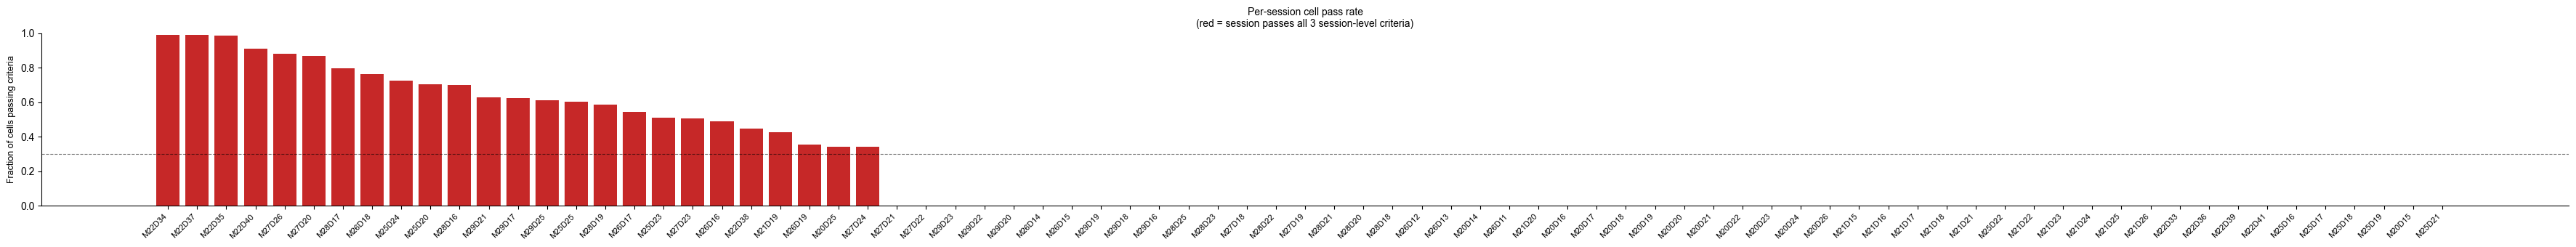


Preview:


,mouse,day,cluster_id,region,cell_corr,cell_agrees,lag1_autocorr,n_cells,agree_frac,var_expl,pc1_enrichment,pc1_dominance,session_passes,passes_criteria
1249,20,25,96,ENT,0.6316,True,0.8128,35,0.3429,0.227,7.9442,2.4951,True,True
1250,20,25,100,ENT,0.4388,True,0.7984,35,0.3429,0.227,7.9442,2.4951,True,True
1251,20,25,103,ENT,0.7209,True,0.8283,35,0.3429,0.227,7.9442,2.4951,True,True
1253,20,25,121,ENT,0.6872,True,0.7951,35,0.3429,0.227,7.9442,2.4951,True,True
1255,20,25,157,ENT,0.3759,True,0.7033,35,0.3429,0.227,7.9442,2.4951,True,True
1269,20,25,83,ENT,0.7001,True,0.8363,35,0.3429,0.227,7.9442,2.4951,True,True
1270,20,25,102,ENT,0.7444,True,0.7985,35,0.3429,0.227,7.9442,2.4951,True,True
1271,20,25,106,ENT,0.6408,True,0.8134,35,0.3429,0.227,7.9442,2.4951,True,True
1272,20,25,107,ENT,0.4214,True,0.7821,35,0.3429,0.227,7.9442,2.4951,True,True
1273,20,25,111,ENT,0.8166,True,0.8367,35,0.3429,0.227,7.9442,2.4951,True,True


In [14]:
%matplotlib inline
from IPython.display import display as _disp

if not cell_rows:
    print('No cell records — run cell-main first')
else:
    df_cells = pd.DataFrame(cell_rows)

    FLAGS_CSV = (Path('/Users/harryclark/Documents/spatial-manifolds/data/')
                 / 'task_anchoring_cell_flags.csv')
    df_cells.to_csv(FLAGS_CSV, index=False)
    print(f'Saved: {FLAGS_CSV}')
    print(f'Rows: {len(df_cells)}')

    n_sessions      = df_cells[['mouse','day']].drop_duplicates().shape[0]
    n_sess_pass     = df_cells[df_cells['session_passes']][['mouse','day']].drop_duplicates().shape[0]
    n_cells_total   = len(df_cells)
    n_cells_pass    = df_cells['passes_criteria'].sum()

    print(f'\nSessions:  {n_sess_pass}/{n_sessions} pass session-level criteria')
    print(f'Cells:     {n_cells_pass}/{n_cells_total} pass combined criteria  '
          f'({100*n_cells_pass/n_cells_total:.1f}%)')

    # Breakdown by region
    for reg in sorted(df_cells['region'].unique()):
        sub = df_cells[df_cells['region'] == reg]
        n_p = sub['passes_criteria'].sum()
        print(f'  {reg}: {n_p}/{len(sub)} ({100*n_p/len(sub):.1f}%)')

    # Quick bar: pass rate per session
    sess_summary = (df_cells.groupby(['mouse','day'])
                    .agg(n_cells=('cluster_id','count'),
                         n_pass=('passes_criteria','sum'),
                         session_passes=('session_passes','first'))
                    .reset_index())
    sess_summary['pass_rate'] = sess_summary['n_pass'] / sess_summary['n_cells']
    sess_summary = sess_summary.sort_values('pass_rate', ascending=False)

    fig_fl, ax_fl = plt.subplots(figsize=(max(5, len(sess_summary) * 0.45), 3.5))
    xlabels_fl = [f"M{int(r.mouse)}D{int(r.day)}" for _, r in sess_summary.iterrows()]
    colors_fl  = ['#c62828' if r.session_passes else '#90a4ae'
                  for _, r in sess_summary.iterrows()]
    ax_fl.bar(np.arange(len(sess_summary)), sess_summary['pass_rate'],
              color=colors_fl, edgecolor='none')
    ax_fl.axhline(0.3, color='k', lw=0.8, ls='--', alpha=0.5)
    ax_fl.set_xticks(np.arange(len(sess_summary)))
    ax_fl.set_xticklabels(xlabels_fl, rotation=45, ha='right', fontsize=8)
    ax_fl.set_ylabel('Fraction of cells passing criteria', fontsize=9)
    ax_fl.set_ylim(0, 1)
    ax_fl.set_title('Per-session cell pass rate\n(red = session passes all 3 session-level criteria)',
                    fontsize=10)
    ax_fl.spines['top'].set_visible(False); ax_fl.spines['right'].set_visible(False)
    fig_fl.tight_layout()
    _disp(fig_fl)
    plt.close(fig_fl)

    print('\nPreview:')
    _disp(df_cells[df_cells['passes_criteria']].head(10))

## Validation: streakiness of passing vs. failing cells

Cells that pass the inclusion criteria should show clear temporal persistence in
their anchoring state — long runs of consecutive anchored or non-anchored trials.
Cells that fail should look more like random noise.

**Metric: lag-k autocorrelation of the binary anchoring sequence.**
For a streaky cell, consecutive trials tend to share the same state, so the
autocorrelation at short lags is high and decays slowly.  The complement
`1 - ρ(lag=1)` is the **transition rate** — the probability that a cell switches
anchoring state between adjacent trials.  Noisy cells have a transition rate
near 0.5 (random coin flip); streaky cells have a transition rate near 0.

### Panels

- **Left**: Mean ± SEM autocorrelogram (lags 1–20 trials) for passing cells
  (green) vs. failing cells (grey).  Streaky cells should show sustained
  positive autocorrelation across many lags; noise should collapse to zero
  at lag 1.
- **Right**: Distribution of `1 - ρ(lag=1)` per cell for each group (violin +
  individual points).  A Mann-Whitney U test confirms whether the groups
  differ significantly.

Mann-Whitney U  pass vs fail  1-lag1_autocorr:  U=9261228  p=7.58e-09
Passing cells n=2149  median 1-rho=0.195
Failing cells n=7985  median 1-rho=0.214


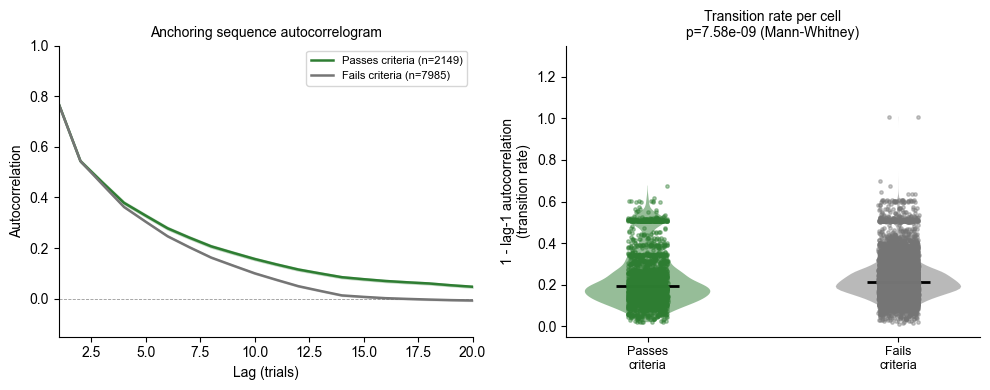

In [15]:
%matplotlib inline
from IPython.display import display as _disp
from scipy.stats import mannwhitneyu

if not acf_data:
    print('Run cell-main first')
else:
    MAX_LAG  = 20
    lags     = np.arange(1, MAX_LAG + 1)

    pass_acf = np.array([r['acf'][:MAX_LAG] for r in acf_data if r['passes_criteria']],
                        dtype=float)
    fail_acf = np.array([r['acf'][:MAX_LAG] for r in acf_data if not r['passes_criteria']],
                        dtype=float)

    def _mean_sem(mat):
        mean = np.nanmean(mat, axis=0)
        sem  = np.nanstd(mat, axis=0) / np.sqrt(np.sum(~np.isnan(mat), axis=0))
        return mean, sem

    pass_mean, pass_sem = _mean_sem(pass_acf)
    fail_mean, fail_sem = _mean_sem(fail_acf)

    # Lag-1 autocorr per cell for violin
    pass_lag1 = pass_acf[:, 0][~np.isnan(pass_acf[:, 0])]
    fail_lag1 = fail_acf[:, 0][~np.isnan(fail_acf[:, 0])]

    stat, pval = mannwhitneyu(pass_lag1, fail_lag1, alternative='greater')
    print(f'Mann-Whitney U  pass vs fail  1-lag1_autocorr:  U={stat:.0f}  p={pval:.2e}')
    print(f'Passing cells n={len(pass_lag1)}  median 1-rho={1-np.median(pass_lag1):.3f}')
    print(f'Failing cells n={len(fail_lag1)}  median 1-rho={1-np.median(fail_lag1):.3f}')

    fig_val, (ax_acf, ax_vio) = plt.subplots(1, 2, figsize=(10, 4))

    # --- Autocorrelogram ---
    ax_acf.axhline(0, color='k', lw=0.6, ls='--', alpha=0.4)
    for mean, sem, color, label, n in [
        (pass_mean, pass_sem, '#2e7d32', f'Passes criteria (n={len(pass_lag1)})', len(pass_lag1)),
        (fail_mean, fail_sem, '#757575', f'Fails criteria (n={len(fail_lag1)})',  len(fail_lag1)),
    ]:
        ax_acf.fill_between(lags, mean - sem, mean + sem, alpha=0.25, color=color)
        ax_acf.plot(lags, mean, color=color, lw=1.8, label=label)
    ax_acf.set_xlabel('Lag (trials)', fontsize=10)
    ax_acf.set_ylabel('Autocorrelation', fontsize=10)
    ax_acf.set_title('Anchoring sequence autocorrelogram', fontsize=10)
    ax_acf.set_xlim(1, MAX_LAG); ax_acf.set_ylim(-0.15, 1.0)
    ax_acf.legend(fontsize=8)
    ax_acf.spines['top'].set_visible(False); ax_acf.spines['right'].set_visible(False)

    # --- Violin: 1 - lag-1 autocorr ---
    trans_pass = 1 - pass_lag1
    trans_fail = 1 - fail_lag1
    vdata  = [trans_pass, trans_fail]
    colors = ['#2e7d32', '#757575']
    parts  = ax_vio.violinplot(vdata, positions=[1, 2], showmedians=True, showextrema=False)
    for pc, col in zip(parts['bodies'], colors):
        pc.set_facecolor(col); pc.set_alpha(0.5)
    parts['cmedians'].set_color('k'); parts['cmedians'].set_linewidth(2)
    rng = np.random.default_rng(0)
    for xi, arr, col in zip([1, 2], vdata, colors):
        jitter = rng.uniform(-0.08, 0.08, len(arr))
        ax_vio.scatter(xi + jitter, arr, s=6, alpha=0.4, color=col, zorder=3)
    ax_vio.set_xticks([1, 2])
    ax_vio.set_xticklabels(['Passes\ncriteria', 'Fails\ncriteria'], fontsize=9)
    ax_vio.set_ylabel('1 - lag-1 autocorrelation\n(transition rate)', fontsize=10)
    ax_vio.set_title(f'Transition rate per cell\np={pval:.2e} (Mann-Whitney)', fontsize=10)
    ax_vio.set_ylim(-0.05, 1.35)
    ax_vio.spines['top'].set_visible(False); ax_vio.spines['right'].set_visible(False)

    fig_val.tight_layout()
    _disp(fig_val)
    plt.close(fig_val)

In [16]:
%matplotlib inline
from IPython.display import display as _disp
from scipy import stats as _stats

# ── Build dataset: passing sessions that are multi-shank ──────────────────────
if 'df_cells' not in dir():
    df_cells = pd.DataFrame(cell_rows)

df_pass = df_cells[df_cells['session_passes']].copy()

# Identify multi-shank sessions using shank_id in df_all
shank_counts = (
    df_all.groupby(['mouse', 'day'])['shank_id']
    .nunique()
    .reset_index()
    .rename(columns={'shank_id': 'n_shanks'})
)
passing_set    = set(map(tuple, df_pass[['mouse', 'day']].values))
multishank_set = set(
    map(tuple, shank_counts[shank_counts['n_shanks'] > 1][['mouse', 'day']].values)
)
passing_multishank = passing_set & multishank_set
print(f'Passing sessions: {len(passing_set)}  '
      f'of which multi-shank: {len(passing_multishank)}')

# Merge coord_SCs_x from locs (sign convention: medial < MEDLAT_BOUNDARY)
if 'locs' not in dir():
    locs = pd.read_csv(f'{SOURCE_PATH}/all_cluster_brain_locations_chris.csv')
    locs['coord_SCs_x'] = locs['coord_SCs_x'] * -1

df_ml = (
    df_pass
    .merge(locs[['mouse', 'day', 'cluster_id', 'coord_SCs_x']],
           on=['mouse', 'day', 'cluster_id'], how='left')
    .merge(df_all[['mouse', 'day', 'cluster_id', 'shank_id']],
           on=['mouse', 'day', 'cluster_id'], how='left')
)
df_ml = df_ml[
    df_ml.apply(lambda r: (r['mouse'], r['day']) in passing_multishank, axis=1)
].dropna(subset=['coord_SCs_x', 'cell_corr']).copy()

df_ml['medlat'] = df_ml['coord_SCs_x'].apply(
    lambda x: 'medial' if x < MEDLAT_BOUNDARY else 'lateral'
)

n_sess = df_ml.groupby(['mouse', 'day']).ngroups
print(f'{n_sess} sessions, {len(df_ml)} cells')
print(df_ml['medlat'].value_counts().to_string())
print('\nRegion breakdown:')
print(df_ml.groupby(['region', 'medlat']).size().unstack(fill_value=0).to_string())


Passing sessions: 25  of which multi-shank: 10
10 sessions, 1782 cells
medlat
medial     1179
lateral     603

Region breakdown:
medlat  lateral  medial
region                 
ENT         477     318
PAR          13     141
PRE           0     191
SUB           0     138
VIS         113     391


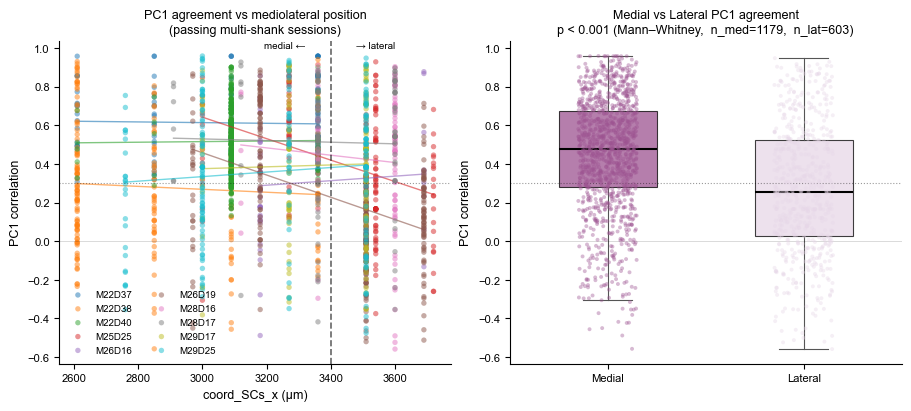

In [17]:
medial_corr  = df_ml[df_ml['medlat'] == 'medial' ]['cell_corr'].values
lateral_corr = df_ml[df_ml['medlat'] == 'lateral']['cell_corr'].values
stat, pval   = _stats.mannwhitneyu(medial_corr, lateral_corr, alternative='two-sided')
ptext        = f'p = {pval:.3f}' if pval >= 0.001 else 'p < 0.001'

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)

# ── Scatter: coord_SCs_x vs cell_corr, one line per session ──────────────────
ax1   = axes[0]
sess  = list(df_ml.groupby(['mouse', 'day']))
cmap_s = plt.cm.get_cmap('tab10', len(sess))

for si, ((m, d), grp) in enumerate(sess):
    ax1.scatter(grp['coord_SCs_x'], grp['cell_corr'],
                color=cmap_s(si), s=15, alpha=0.5, edgecolors='none',
                label=f'M{m}D{d}', zorder=2)
    if len(grp) > 2:
        sl, ic, r, p, _ = _stats.linregress(grp['coord_SCs_x'], grp['cell_corr'])
        xs = np.array([grp['coord_SCs_x'].min(), grp['coord_SCs_x'].max()])
        ax1.plot(xs, sl * xs + ic, color=cmap_s(si), lw=1.0, alpha=0.6)

ax1.axvline(MEDLAT_BOUNDARY, color='k', lw=1.2, ls='--', alpha=0.6)
ax1.axhline(0.3, color='k', lw=0.8, ls=':', alpha=0.4)
ax1.axhline(0.0, color='k', lw=0.5, alpha=0.2)
ylims = ax1.get_ylim()
ax1.text(MEDLAT_BOUNDARY + 80,  ylims[1], '→ lateral', fontsize=7, va='top')
ax1.text(MEDLAT_BOUNDARY - 80,  ylims[1], 'medial ←', fontsize=7, va='top', ha='right')
ax1.set_xlabel('coord_SCs_x (µm)', fontsize=9)
ax1.set_ylabel('PC1 correlation', fontsize=9)
ax1.set_title('PC1 agreement vs mediolateral position\n(passing multi-shank sessions)',
              fontsize=9)
ax1.legend(fontsize=7, frameon=False, ncol=2)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(labelsize=8)

# ── Boxplot + strip: medial vs lateral ───────────────────────────────────────
ax2     = axes[1]
rng     = np.random.default_rng(0)
data_ml = [medial_corr, lateral_corr]
colors  = ['#9d5391', '#e7d7e8']

bp = ax2.boxplot(data_ml, patch_artist=True, widths=0.5,
                 labels=['Medial', 'Lateral'],
                 medianprops=dict(color='k', lw=1.5),
                 whiskerprops=dict(lw=0.8, color='#555'),
                 capprops=dict(lw=0.8, color='#555'),
                 flierprops=dict(marker='o', ms=2, alpha=0.3, markeredgewidth=0))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75); patch.set_linewidth(0.8)
for xi, (d, color) in enumerate(zip(data_ml, colors), start=1):
    jitter = rng.uniform(-0.15, 0.15, size=len(d))
    ax2.scatter(xi + jitter, d, color=color, s=8, alpha=0.4, zorder=3, edgecolors='none')

ax2.axhline(0.3, color='k', lw=0.8, ls=':', alpha=0.4)
ax2.axhline(0.0, color='k', lw=0.5, alpha=0.2)
ax2.set_ylabel('PC1 correlation', fontsize=9)
ax2.set_title(
    f'Medial vs Lateral PC1 agreement\n'
    f'{ptext} (Mann–Whitney,  n_med={len(medial_corr)},  n_lat={len(lateral_corr)})',
    fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(labelsize=8)

_disp(fig)
plt.close(fig)


ENT cells: 795  (7 sessions)  medial=318  lateral=477


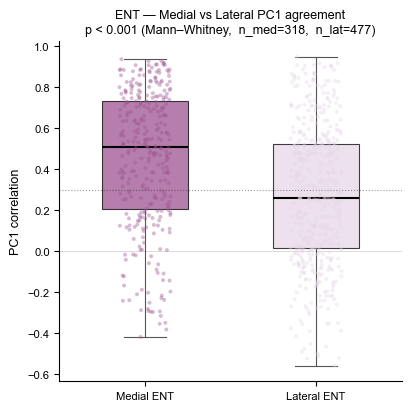

In [18]:
# ── Medial vs Lateral PC1 agreement — ENT cells only ─────────────────────────
df_ent_ml = df_ml[df_ml['region'] == 'ENT'].copy()

med_ent  = df_ent_ml[df_ent_ml['medlat'] == 'medial' ]['cell_corr'].values
lat_ent  = df_ent_ml[df_ent_ml['medlat'] == 'lateral']['cell_corr'].values
stat_e, pval_e = _stats.mannwhitneyu(med_ent, lat_ent, alternative='two-sided')
ptext_e  = f'p = {pval_e:.3f}' if pval_e >= 0.001 else 'p < 0.001'

n_sess_ent = df_ent_ml.groupby(['mouse', 'day']).ngroups
print(f'ENT cells: {len(df_ent_ml)}  ({n_sess_ent} sessions)  '
      f'medial={len(med_ent)}  lateral={len(lat_ent)}')

fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)
rng    = np.random.default_rng(0)
data_e = [med_ent, lat_ent]
colors = ['#9d5391', '#e7d7e8']

bp = ax.boxplot(data_e, patch_artist=True, widths=0.5,
                labels=['Medial ENT', 'Lateral ENT'],
                medianprops=dict(color='k', lw=1.5),
                whiskerprops=dict(lw=0.8, color='#555'),
                capprops=dict(lw=0.8, color='#555'),
                flierprops=dict(marker='o', ms=2, alpha=0.3, markeredgewidth=0))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75); patch.set_linewidth(0.8)
for xi, (d, color) in enumerate(zip(data_e, colors), start=1):
    jitter = rng.uniform(-0.15, 0.15, size=len(d))
    ax.scatter(xi + jitter, d, color=color, s=8, alpha=0.4, zorder=3, edgecolors='none')

ax.axhline(0.3, color='k', lw=0.8, ls=':', alpha=0.4)
ax.axhline(0.0, color='k', lw=0.5, alpha=0.2)
ax.set_ylabel('PC1 correlation', fontsize=9)
ax.set_title(
    f'ENT — Medial vs Lateral PC1 agreement\n'
    f'{ptext_e} (Mann–Whitney,  n_med={len(med_ent)},  n_lat={len(lat_ent)})',
    fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=8)

_disp(fig)
plt.close(fig)


ENT lag-1 autocorr: medial n=302  lateral n=433


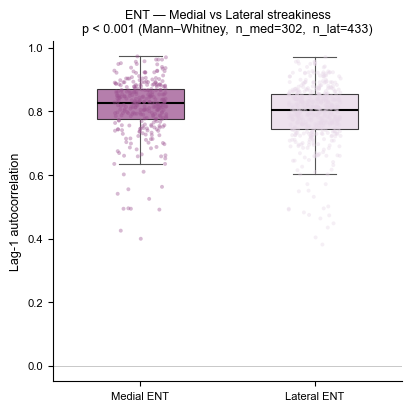

In [19]:
# ── Medial vs Lateral lag-1 autocorrelation — ENT cells ──────────────────────
df_ent_acf = df_ent_ml.dropna(subset=['lag1_autocorr']).copy()

med_acf = df_ent_acf[df_ent_acf['medlat'] == 'medial' ]['lag1_autocorr'].values
lat_acf = df_ent_acf[df_ent_acf['medlat'] == 'lateral']['lag1_autocorr'].values
stat_a, pval_a = _stats.mannwhitneyu(med_acf, lat_acf, alternative='two-sided')
ptext_a = f'p = {pval_a:.3f}' if pval_a >= 0.001 else 'p < 0.001'

print(f'ENT lag-1 autocorr: medial n={len(med_acf)}  lateral n={len(lat_acf)}')

fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)
rng    = np.random.default_rng(0)
data_a = [med_acf, lat_acf]
colors = ['#9d5391', '#e7d7e8']

bp = ax.boxplot(data_a, patch_artist=True, widths=0.5,
                labels=['Medial ENT', 'Lateral ENT'],
                medianprops=dict(color='k', lw=1.5),
                whiskerprops=dict(lw=0.8, color='#555'),
                capprops=dict(lw=0.8, color='#555'),
                flierprops=dict(marker='o', ms=2, alpha=0.3, markeredgewidth=0))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75); patch.set_linewidth(0.8)
for xi, (d, color) in enumerate(zip(data_a, colors), start=1):
    jitter = rng.uniform(-0.15, 0.15, size=len(d))
    ax.scatter(xi + jitter, d, color=color, s=8, alpha=0.4, zorder=3, edgecolors='none')

ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.set_ylabel('Lag-1 autocorrelation', fontsize=9)
ax.set_title(
    f'ENT — Medial vs Lateral streakiness\n'
    f'{ptext_a} (Mann–Whitney,  n_med={len(med_acf)},  n_lat={len(lat_acf)})',
    fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=8)

_disp(fig)
plt.close(fig)


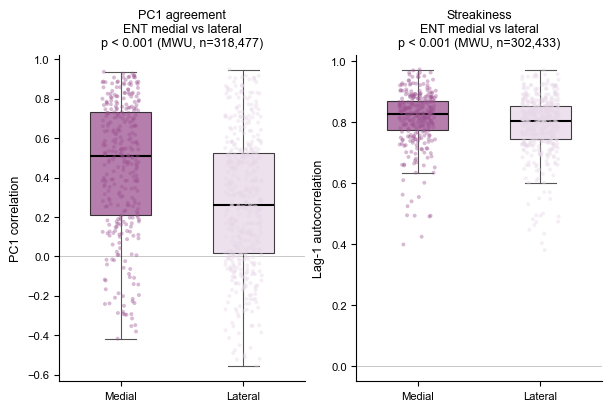

In [20]:
# ── Combined: PC1 correlation + lag-1 autocorrelation, medial vs lateral ENT ─
df_ent_ml  = df_ml[df_ml['region'] == 'ENT'].copy()
df_ent_acf = df_ent_ml.dropna(subset=['lag1_autocorr'])

med_pc1 = df_ent_ml[df_ent_ml['medlat'] == 'medial' ]['cell_corr'].values
lat_pc1 = df_ent_ml[df_ent_ml['medlat'] == 'lateral']['cell_corr'].values
med_acf = df_ent_acf[df_ent_acf['medlat'] == 'medial' ]['lag1_autocorr'].values
lat_acf = df_ent_acf[df_ent_acf['medlat'] == 'lateral']['lag1_autocorr'].values

_, pval_pc1 = _stats.mannwhitneyu(med_pc1, lat_pc1, alternative='two-sided')
_, pval_acf = _stats.mannwhitneyu(med_acf, lat_acf, alternative='two-sided')
ptext_pc1 = f'p = {pval_pc1:.3f}' if pval_pc1 >= 0.001 else 'p < 0.001'
ptext_acf = f'p = {pval_acf:.3f}' if pval_acf >= 0.001 else 'p < 0.001'

fig, axes = plt.subplots(1, 2, figsize=(6, 4), constrained_layout=True)
rng    = np.random.default_rng(0)
colors = ['#9d5391', '#e7d7e8']

def _boxplot_panel(ax, data_list, ylabel, title):
    bp = ax.boxplot(data_list, patch_artist=True, widths=0.5,
                    labels=['Medial', 'Lateral'],
                    medianprops=dict(color='k', lw=1.5),
                    whiskerprops=dict(lw=0.8, color='#555'),
                    capprops=dict(lw=0.8, color='#555'),
                    flierprops=dict(marker='o', ms=2, alpha=0.3, markeredgewidth=0))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.75); patch.set_linewidth(0.8)
    for xi, (d, color) in enumerate(zip(data_list, colors), start=1):
        jitter = rng.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(xi + jitter, d, color=color, s=8, alpha=0.4, zorder=3, edgecolors='none')
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

_boxplot_panel(axes[0], [med_pc1, lat_pc1],
               ylabel='PC1 correlation',
               title=f'PC1 agreement\nENT medial vs lateral\n{ptext_pc1} (MWU, n={len(med_pc1)},{len(lat_pc1)})')

_boxplot_panel(axes[1], [med_acf, lat_acf],
               ylabel='Lag-1 autocorrelation',
               title=f'Streakiness\nENT medial vs lateral\n{ptext_acf} (MWU, n={len(med_acf)},{len(lat_acf)})')

_disp(fig)
plt.close(fig)


## Field shuffle null model for anchoring streakiness

The field shuffle is a spatially-structured null that asks: *"is the measured
streakiness above what you would expect if the cell's firing fields were placed
randomly on the track?"*

### Algorithm

**Step 1 — Flatten and smooth.**
The per-trial firing rate map (`n_trials × n_pos_bins`) is flattened to a single
1-D trace of length `n_trials × n_pos_bins`. A wide Gaussian kernel (σ ≈ 3 bins)
is applied to this trace to create a smooth version used only for peak detection.

**Step 2 — Detect firing fields.**
Peaks are found in the smoothed trace with a minimum separation constraint
(`min_distance = n_pos_bins / 5`). For each peak the algorithm walks left and
right until the trace stops descending — the turning points become the left and
right boundaries of that field. Every position bin is labelled with the index
of the field it belongs to (0 = background).

**Step 3 — Randomly place fields, preserving shape.**
Fields are placed in a randomised order. For each field:
1. A random *empty* bin is chosen as the new peak location.
2. The algorithm walks left from that bin, filling each empty slot with the
   original firing rate from the corresponding offset within the real field
   (circular wrap at the array boundaries; if a slot is already occupied it
   skips to the next empty one).
3. The same walk-right procedure fills the right side of the field.

**Step 4 — Redistribute background bins.**
Bins not belonging to any field are collected; their original firing-rate values
are randomly permuted among the remaining unfilled slots in the shuffled map.

### What the shuffle preserves and destroys

| Property | Preserved | Destroyed |
|---|:---:|:---:|
| Total firing rate | ✓ | |
| Field shape (amplitude, width profile) | ✓ | |
| Number of fields | ✓ | |
| Spatial phase-lock to track harmonics | | ✓ |
| Trial-to-trial firing-rate variability | ~ | |

The shuffled map is then passed through the **same spectral-analysis pipeline**
as the real data to produce shuffled anchoring labels, from which the lag-1
autocorrelation is computed. Repeating this `N_SHUFFLES` times per cell gives a
null distribution for streakiness that controls for firing-rate statistics and
field morphology.


In [ ]:
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks as _sp_find_peaks

def _find_field_extent(tc_smooth, peak_idx):
    """Walk left/right from a peak to find the neighbouring local minima."""
    n = len(tc_smooth)
    r = peak_idx
    for i in range(peak_idx, n):
        if np.isnan(tc_smooth[i]): continue
        if   tc_smooth[i] < tc_smooth[r]: r = i
        elif tc_smooth[i] > tc_smooth[r]: break
    l = peak_idx
    for i in range(peak_idx, -1, -1):
        if np.isnan(tc_smooth[i]): continue
        if   tc_smooth[i] < tc_smooth[l]: l = i
        elif tc_smooth[i] > tc_smooth[l]: break
    return l, r


def _field_shuffle_tc(tc, bpt, sigma_extra=3.0, rng=None):
    """
    Single field shuffle of a flattened TC (length n_trials * bpt).
    Preserves field shape; randomises field placement on the track.
    """
    if rng is None:
        rng = np.random.default_rng()
    n        = (len(tc) // bpt) * bpt
    tc_orig  = np.nan_to_num(tc[:n].astype(float), nan=0.0)
    tc_sm    = gaussian_filter1d(tc_orig, sigma=sigma_extra)
    min_dist = max(bpt // 5, 3)

    peaks_i, _ = _sp_find_peaks(tc_sm, distance=min_dist)
    if len(peaks_i) == 0:
        out = tc_orig.copy(); rng.shuffle(out); return out

    extents   = [_find_field_extent(tc_sm, p) for p in peaks_i]
    field_arr = np.zeros(n, dtype=np.int64)
    for fi, (l, r) in enumerate(extents):
        field_arr[l:r+1] = fi + 1

    fr         = np.full(n, np.nan)
    used_dest  = []
    used_src   = []

    for fi in rng.permutation(len(peaks_i)):
        pi, (l, r) = int(peaks_i[fi]), extents[fi]
        fl   = pi - l
        fr_r = r - pi

        empty = np.where(np.isnan(fr))[0]
        if len(empty) == 0: break
        new_peak = int(rng.choice(empty))
        fr[new_peak] = tc_orig[pi]
        used_dest.append(new_peak); used_src.append(pi)

        # walk left
        j = new_peak
        for offset in range(1, fl + 1):
            j = (j - 1) % n
            guard = 0
            while not np.isnan(fr[j]) and guard < n:
                j = (j - 1) % n; guard += 1
            if guard >= n: break
            fr[j] = tc_orig[max(0, pi - offset)]
            used_dest.append(j); used_src.append(max(0, pi - offset))

        # walk right
        j = new_peak
        for offset in range(1, fr_r + 1):
            j = (j + 1) % n
            guard = 0
            while not np.isnan(fr[j]) and guard < n:
                j = (j + 1) % n; guard += 1
            if guard >= n: break
            fr[j] = tc_orig[min(n - 1, pi + offset)]
            used_dest.append(j); used_src.append(min(n - 1, pi + offset))

    # redistribute background bins
    all_idx    = set(range(n))
    empty_dest = np.array(sorted(all_idx - set(used_dest)))
    unused_src = np.array(sorted(all_idx - set(used_src)))
    if len(empty_dest) > 0 and len(unused_src) > 0:
        rng.shuffle(unused_src)
        for i, di in enumerate(empty_dest):
            fr[di] = tc_orig[unused_src[i % len(unused_src)]]

    return np.nan_to_num(fr, nan=0.0)


def _anchoring_labels_from_tc(tc):
    """Run the anchoring pipeline directly on a TC array (no cell-id lookup)."""
    _ID = 88888
    try:
        results     = spectral_analysis({_ID: tc, _ID + 1: tc}, tl, bs)
        fvalid      = results[5]
        freq_idx    = [int(np.argmin(np.abs(fvalid - f))) for f in TARGET_FREQS]
        lbl_per_win = np.isin(np.argmax(results[3][0], axis=0), freq_idx).astype(int)
        labels      = get_kmeans_spatial_labels(tc, lbl_per_win, bs=bs, tl=tl).astype(float)
        edge        = int(1600 / (2 * (tl / bs)))
        labels[:edge] = np.nan; labels[-edge:] = np.nan
        return labels
    except Exception:
        return None


: 

In [ ]:
N_SHUFFLES = 50   # reduce if slow; increase for tighter CIs

shuffle_rows = []   # one row per (cell, shuffle_index)
real_frac_rows = [] # one row per cell — real frac_anchored computed here

def _frac_anchored(labels):
    v = np.asarray(labels, dtype=float)
    valid = v[~np.isnan(v)]
    return float(np.mean(valid == 1)) if len(valid) > 0 else np.nan

for (mouse, day), sess_df in df_ent_ml.groupby(['mouse', 'day']):
    print(f'M{mouse}D{day}: {len(sess_df)} ENT cells × {N_SHUFFLES} shuffles …')
    try:
        tcs_s, _, _, _, _, _ = compute_vr_tcs(mouse, day, source_path=SOURCE_PATH)
    except Exception as e:
        print(f'  load error: {e}'); continue

    for _, row in sess_df.iterrows():
        cid    = int(row['cluster_id'])
        ml     = row['medlat']
        tc_raw = tcs_s.get(cid)
        if tc_raw is None: continue
        tc_arr = np.nan_to_num(np.asarray(tc_raw, dtype=float), nan=0.0)

        # Real frac_anchored from the actual TC
        lab_real = _anchoring_labels_from_tc(tc_arr)
        fa_real  = _frac_anchored(lab_real) if lab_real is not None else np.nan
        real_frac_rows.append({'mouse': mouse, 'day': day, 'cluster_id': cid,
                               'medlat': ml, 'frac_anchored_real': fa_real})

        for si in range(N_SHUFFLES):
            tc_shuf  = _field_shuffle_tc(tc_arr, bpt=int(tl / bs),
                                          rng=np.random.default_rng(si))
            lab_shuf = _anchoring_labels_from_tc(tc_shuf)
            if lab_shuf is None: continue
            lag1 = _cell_autocorr(lab_shuf, max_lag=1)[0]
            fa   = _frac_anchored(lab_shuf)
            shuffle_rows.append({'mouse': mouse, 'day': day, 'cluster_id': cid,
                                 'medlat': ml, 'lag1_shuffle': float(lag1),
                                 'frac_anchored_shuffle': fa})

df_shuffle      = pd.DataFrame(shuffle_rows)
df_real_frac    = pd.DataFrame(real_frac_rows)
print(f'\nDone — {len(df_shuffle)} shuffle records, '
      f'{len(df_real_frac)} real-frac records')


M22D37: 2 ENT cells × 50 shuffles …
M25D25: 65 ENT cells × 50 shuffles …
M26D19: 261 ENT cells × 50 shuffles …
M28D16: 100 ENT cells × 50 shuffles …
M28D17: 70 ENT cells × 50 shuffles …
M29D17: 144 ENT cells × 50 shuffles …
M29D25: 153 ENT cells × 50 shuffles …


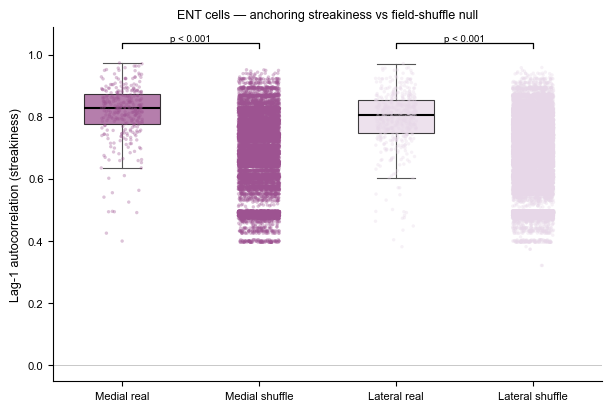

In [ ]:
# Collect real and shuffle lag-1 autocorr for medial and lateral ENT
df_ent_acf2 = df_ent_ml.dropna(subset=['lag1_autocorr'])

med_real = df_ent_acf2[df_ent_acf2['medlat'] == 'medial' ]['lag1_autocorr'].values
lat_real = df_ent_acf2[df_ent_acf2['medlat'] == 'lateral']['lag1_autocorr'].values
med_shuf = df_shuffle[df_shuffle['medlat'] == 'medial' ]['lag1_shuffle'].values
lat_shuf = df_shuffle[df_shuffle['medlat'] == 'lateral']['lag1_shuffle'].values

_, p_med = _stats.mannwhitneyu(med_real, med_shuf, alternative='two-sided')
_, p_lat = _stats.mannwhitneyu(lat_real, lat_shuf, alternative='two-sided')
def _pstr(p): return f'p = {p:.3f}' if p >= 0.001 else 'p < 0.001'

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
rng = np.random.default_rng(0)

data_list  = [med_real, med_shuf, lat_real, lat_shuf]
labels_bp  = ['Medial real', 'Medial shuffle', 'Lateral real', 'Lateral shuffle']
face_colors = ['#9d5391', '#9d5391', '#e7d7e8', '#e7d7e8']
hatches     = [None, '////',  None, '////']

bp = ax.boxplot(data_list, patch_artist=True, widths=0.55,
                labels=labels_bp,
                medianprops=dict(color='k', lw=1.5),
                whiskerprops=dict(lw=0.8, color='#555'),
                capprops=dict(lw=0.8, color='#555'),
                flierprops=dict(marker='o', ms=2, alpha=0.3, markeredgewidth=0))

for patch, fc, hatch in zip(bp['boxes'], face_colors, hatches):
    patch.set_facecolor(fc); patch.set_alpha(0.75); patch.set_linewidth(0.8)
    if hatch:
        patch.set_hatch(hatch); patch.set_edgecolor('#555')

for xi, (d, fc) in enumerate(zip(data_list, face_colors), start=1):
    jitter = rng.uniform(-0.15, 0.15, size=len(d))
    ax.scatter(xi + jitter, d, color=fc, s=6, alpha=0.35, zorder=3, edgecolors='none')

# Significance brackets
def _bracket(ax, x1, x2, y, p_str, lw=0.9):
    h = 0.015
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, color='k')
    ax.text((x1+x2)/2, y+h, p_str, ha='center', va='bottom', fontsize=7)

ymax = max(np.nanmax(d) for d in data_list) * 1.05
_bracket(ax, 1, 2, ymax,          _pstr(p_med))
_bracket(ax, 3, 4, ymax,          _pstr(p_lat))

ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.set_ylabel('Lag-1 autocorrelation (streakiness)', fontsize=9)
ax.set_title('ENT cells — anchoring streakiness vs field-shuffle null', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=8)

_disp(fig)
plt.close(fig)


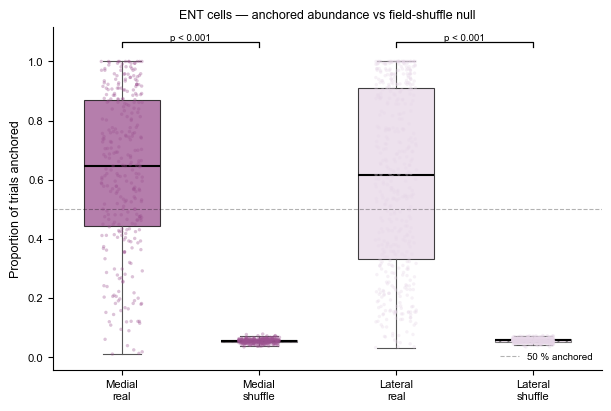

In [ ]:
# Per-cell mean shuffle frac_anchored (one representative value per cell)
shuf_mean = (df_shuffle.groupby(['mouse', 'day', 'cluster_id', 'medlat'])
             ['frac_anchored_shuffle'].mean().reset_index()
             .rename(columns={'frac_anchored_shuffle': 'frac_anch_shuf_mean'}))
df_fa = df_real_frac.merge(shuf_mean, on=['mouse', 'day', 'cluster_id', 'medlat'], how='left')
df_fa = df_fa.dropna(subset=['frac_anchored_real', 'frac_anch_shuf_mean'])

med_real_fa = df_fa[df_fa['medlat'] == 'medial' ]['frac_anchored_real'].values
lat_real_fa = df_fa[df_fa['medlat'] == 'lateral']['frac_anchored_real'].values
med_shuf_fa = df_fa[df_fa['medlat'] == 'medial' ]['frac_anch_shuf_mean'].values
lat_shuf_fa = df_fa[df_fa['medlat'] == 'lateral']['frac_anch_shuf_mean'].values

_, p_med_fa = _stats.mannwhitneyu(med_real_fa, med_shuf_fa, alternative='two-sided')
_, p_lat_fa = _stats.mannwhitneyu(lat_real_fa, lat_shuf_fa, alternative='two-sided')
def _pstr(p): return f'p = {p:.3f}' if p >= 0.001 else 'p < 0.001'

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
rng = np.random.default_rng(0)

data_list   = [med_real_fa, med_shuf_fa, lat_real_fa, lat_shuf_fa]
labels_bp   = ['Medial\nreal', 'Medial\nshuffle', 'Lateral\nreal', 'Lateral\nshuffle']
face_colors = ['#9d5391', '#9d5391', '#e7d7e8', '#e7d7e8']
hatches     = [None, '////', None, '////']

bp = ax.boxplot(data_list, patch_artist=True, widths=0.55,
                labels=labels_bp,
                medianprops=dict(color='k', lw=1.5),
                whiskerprops=dict(lw=0.8, color='#555'),
                capprops=dict(lw=0.8, color='#555'),
                flierprops=dict(marker='o', ms=2, alpha=0.3, markeredgewidth=0))
for patch, fc, hatch in zip(bp['boxes'], face_colors, hatches):
    patch.set_facecolor(fc); patch.set_alpha(0.75); patch.set_linewidth(0.8)
    if hatch: patch.set_hatch(hatch); patch.set_edgecolor('#555')
for xi, (d, fc) in enumerate(zip(data_list, face_colors), start=1):
    jitter = rng.uniform(-0.15, 0.15, size=len(d))
    ax.scatter(xi + jitter, d, color=fc, s=6, alpha=0.35, zorder=3, edgecolors='none')

def _bracket(ax, x1, x2, y, label, lw=0.9):
    h = 0.015
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, color='k')
    ax.text((x1+x2)/2, y+h, label, ha='center', va='bottom', fontsize=7)

ymax = max(np.nanmax(d) for d in data_list) * 1.05
_bracket(ax, 1, 2, ymax,        _pstr(p_med_fa))
_bracket(ax, 3, 4, ymax,        _pstr(p_lat_fa))

ax.axhline(0.5, color='k', lw=0.8, ls='--', alpha=0.3, label='50 % anchored')
ax.set_ylabel('Proportion of trials anchored', fontsize=9)
ax.set_title('ENT cells — anchored abundance vs field-shuffle null', fontsize=9)
ax.legend(fontsize=7, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=8)

_disp(fig)
plt.close(fig)


In [ ]:
# ── 4-panel summary figure: session qualification | abundance | streakiness | PC1 corr
from matplotlib.colors import Normalize

df_ent_ml2  = df_ml[df_ml['region'] == 'ENT'].dropna(subset=['cell_corr', 'lag1_autocorr'])
df_fa       = df_real_frac.merge(
    df_shuffle.groupby(['mouse','day','cluster_id','medlat'])['frac_anchored_shuffle']
    .mean().reset_index().rename(columns={'frac_anchored_shuffle': 'frac_anch_shuf_mean'}),
    on=['mouse','day','cluster_id','medlat'], how='left'
).dropna(subset=['frac_anchored_real', 'frac_anch_shuf_mean'])

med_pc1      = df_ent_ml2[df_ent_ml2['medlat']=='medial' ]['cell_corr'].values
lat_pc1      = df_ent_ml2[df_ent_ml2['medlat']=='lateral']['cell_corr'].values

shuf_lag     = (df_shuffle.groupby(['mouse','day','cluster_id','medlat'])['lag1_shuffle']
                .mean().reset_index())
med_lag_r    = df_ent_ml2[df_ent_ml2['medlat']=='medial' ]['lag1_autocorr'].values
lat_lag_r    = df_ent_ml2[df_ent_ml2['medlat']=='lateral']['lag1_autocorr'].values
med_lag_s    = shuf_lag[shuf_lag['medlat']=='medial' ]['lag1_shuffle'].values
lat_lag_s    = shuf_lag[shuf_lag['medlat']=='lateral']['lag1_shuffle'].values

med_fa_r     = df_fa[df_fa['medlat']=='medial' ]['frac_anchored_real'].values
lat_fa_r     = df_fa[df_fa['medlat']=='lateral']['frac_anchored_real'].values
med_fa_s     = df_fa[df_fa['medlat']=='medial' ]['frac_anch_shuf_mean'].values
lat_fa_s     = df_fa[df_fa['medlat']=='lateral']['frac_anch_shuf_mean'].values

def _pstr(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'
_, p_pc1    = _stats.mannwhitneyu(med_pc1,   lat_pc1,   alternative='two-sided')
_, p_lag_ml = _stats.mannwhitneyu(med_lag_r, lat_lag_r, alternative='two-sided')
_, p_lag_ms = _stats.mannwhitneyu(med_lag_r, med_lag_s, alternative='two-sided')
_, p_lag_ls = _stats.mannwhitneyu(lat_lag_r, lat_lag_s, alternative='two-sided')
_, p_fa_ml  = _stats.mannwhitneyu(med_fa_r,  lat_fa_r,  alternative='two-sided')
_, p_fa_ms  = _stats.mannwhitneyu(med_fa_r,  med_fa_s,  alternative='two-sided')
_, p_fa_ls  = _stats.mannwhitneyu(lat_fa_r,  lat_fa_s,  alternative='two-sided')

# ── Panel A data ──────────────────────────────────────────────────────────────
df_sw = pd.DataFrame(switching_stats)
df_sw['label'] = df_sw.apply(lambda r: f"M{int(r['mouse'])}D{int(r['day'])}", axis=1)

# Medial/lateral boxes are coloured with the same NGS cividis scale used elsewhere
# (medial ≈ 3200 µm, lateral ≈ 3600 µm) so the colour is tied to actual dorsoventral
# position rather than an arbitrary palette. Real = solid, shuffle = hatched.
ngs_cmap   = plt.cm.cividis
ngs_norm   = Normalize(vmin=3000, vmax=3800)
NGSMED_COL = ngs_cmap(ngs_norm(3200))
NGSLAT_COL = ngs_cmap(ngs_norm(3600))

fig, axes = plt.subplots(1, 4, figsize=(13, 4),
                         gridspec_kw=dict(width_ratios=[1.8, 2, 2, 1]),
                         constrained_layout=True)
rng = np.random.default_rng(0)

# ── Panel A: session qualification scatter ────────────────────────────────────
# x = agree_frac   y = pc1_enrichment (log scale)
# point size ∝ pc1_dominance;  black edge = dominance > 2;  red fill = all 3 pass
ax = axes[0]

for _, row in df_sw.iterrows():
    passes = bool(row.get('session_passes', False))
    fc     = '#c62828' if passes else '#90a4ae'
    ec     = 'k'       if row['pc1_dominance'] > 2 else 'none'
    sz     = float(np.clip(row['pc1_dominance'], 0.5, 20)) * 18
    ax.scatter(row['agree_frac'], row['pc1_enrichment'],
               s=sz, color=fc, edgecolors=ec, linewidths=0.7, zorder=3, alpha=0.85)
    ax.text(row['agree_frac'] + 0.015, row['pc1_enrichment'],
            row['label'], fontsize=5.5, va='center', color='#333', zorder=4)

ax.axvline(0.3, color='k', lw=0.8, ls='--', alpha=0.45)
ax.axhline(1.5, color='k', lw=0.8, ls='--', alpha=0.45)
ax.set_yscale('log')
ax.set_xlim(-0.02, 1.10)

# Lightly shade the passing quadrant
_, yhi = ax.get_ylim()
ax.fill_betweenx([1.5, yhi], 0.3, 1.10, color='#c62828', alpha=0.05, zorder=0)

# Size legend for pc1_dominance
for dom_ex, lbl in [(2, 'dom=2'), (10, 'dom=10')]:
    ax.scatter([], [], s=float(np.clip(dom_ex, 0.5, 20)) * 18,
               color='#aaa', edgecolors='k', linewidths=0.7, label=lbl)
ax.legend(fontsize=6, loc='lower right', frameon=False)

ax.set_xlabel('Fraction agreeing cells', fontsize=9)
ax.set_ylabel('PC1 enrichment (×chance)', fontsize=9)
ax.set_title('Session qualification\n(red=pass all 3,  edge=dom>2)', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(labelsize=8)

# ── Shared helpers ────────────────────────────────────────────────────────────
def _draw_boxes(ax, data_list, tick_labels, face_colors, hatches):
    bp = ax.boxplot(data_list, patch_artist=True, widths=0.55,
                    labels=tick_labels,
                    medianprops=dict(color='black', lw=1.5),
                    whiskerprops=dict(lw=0.8, color='#555'),
                    capprops=dict(lw=0.8, color='#555'),
                    flierprops=dict(marker='o', ms=2, alpha=0.3, markeredgewidth=0))
    for patch, fc, hatch in zip(bp['boxes'], face_colors, hatches):
        patch.set_facecolor(fc); patch.set_alpha(0.75); patch.set_linewidth(0.8)
        if hatch: patch.set_hatch(hatch); patch.set_edgecolor('#555')
    for xi, (d, fc) in enumerate(zip(data_list, face_colors), start=1):
        jitter = rng.uniform(-0.15, 0.15, size=len(d))
        ax.scatter(xi + jitter, d, color=fc, s=6, alpha=0.35, zorder=3, edgecolors='none')

def _bracket(ax, x1, x2, y, label, h_frac=0.04):
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * h_frac
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.9, color='k', clip_on=False)
    ax.text((x1+x2)/2, y+h, label, ha='center', va='bottom', fontsize=9)

# ── Panel B: Anchored abundance ───────────────────────────────────────────────
ax = axes[1]
_draw_boxes(ax,
            [med_fa_r, med_fa_s, lat_fa_r, lat_fa_s],
            ['Med\nreal','Med\nshuf','Lat\nreal','Lat\nshuf'],
            [NGSMED_COL, NGSMED_COL, NGSLAT_COL, NGSLAT_COL],
            [None, '////', None, '////'])
ax.axhline(0.5, color='k', lw=0.8, ls='--', alpha=0.35)
ymax = max(np.nanmax(d) for d in [med_fa_r, med_fa_s, lat_fa_r, lat_fa_s]) * 1.05
_bracket(ax, 1, 2, ymax,        _pstr(p_fa_ms))
_bracket(ax, 3, 4, ymax,        _pstr(p_fa_ls))
_bracket(ax, 1, 3, ymax*1.12,   _pstr(p_fa_ml))
ax.set_ylabel('Proportion anchored', fontsize=9)
ax.set_title('Anchored abundance', fontsize=9)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=8)

# ── Panel C: Streakiness ──────────────────────────────────────────────────────
ax = axes[2]
_draw_boxes(ax,
            [med_lag_r, med_lag_s, lat_lag_r, lat_lag_s],
            ['Med\nreal','Med\nshuf','Lat\nreal','Lat\nshuf'],
            [NGSMED_COL, NGSMED_COL, NGSLAT_COL, NGSLAT_COL],
            [None, '////', None, '////'])
ax.axhline(0, color='k', lw=0.5, alpha=0.2)
ymax = max(np.nanmax(d) for d in [med_lag_r, med_lag_s, lat_lag_r, lat_lag_s]) * 1.05
_bracket(ax, 1, 2, ymax,        _pstr(p_lag_ms))
_bracket(ax, 3, 4, ymax,        _pstr(p_lag_ls))
_bracket(ax, 1, 3, ymax*1.12,   _pstr(p_lag_ml))
ax.set_ylabel('Lag-1 autocorrelation', fontsize=9)
ax.set_title('Streakiness', fontsize=9)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=8)

# ── Panel D: PC1 correlation ───────────────────────────────────────────────────
ax = axes[3]
_draw_boxes(ax, [med_pc1, lat_pc1],
            ['Medial', 'Lateral'], [NGSMED_COL, NGSLAT_COL], [None, None])
ax.axhline(0.3, color='k', lw=0.8, ls=':', alpha=0.4)
ax.axhline(0,   color='k', lw=0.5, alpha=0.2)
ymax = max(np.nanmax(med_pc1), np.nanmax(lat_pc1)) * 1.05
_bracket(ax, 1, 2, ymax, _pstr(p_pc1))
ax.set_ylabel('PC1 correlation', fontsize=9)
ax.set_title('PC1 agreement', fontsize=9)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=8)

_disp(fig)
plt.close(fig)